<a href="https://colab.research.google.com/github/sebastiancasas10/ProyectoIA-Migracion/blob/main/Colab_Proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  Codigo del proyecto
  

# Librerias y Drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import os
import re
import unicodedata

#Concat, filtro y merge 2022


In [ ]:
base_path = "/content/drive/MyDrive/GEIH"
year = "2022"
mod = "M"   #  CG, FT, M, O

# LIMPIAR COLUMNAS

def estandarizar_columnas(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.normalize('NFKD')
        .str.encode('ascii', 'ignore')
        .str.decode('utf-8')
        .str.replace(" ", "_")
        .str.replace(r"[^\w_]", "", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    df = df.loc[:, ~df.columns.duplicated()]
    return df

# LECTURA ROBUSTA (SIEMPRE TERMINA BIEN)

def leer_csv_robusto(ruta):

    df = pd.read_csv(ruta, encoding="latin-1", sep=";", low_memory=False)

    if df.shape[1] == 1:
        print("    venía con ',' → corrigiendo")
        df = pd.read_csv(ruta, encoding="latin-1", sep=",", low_memory=False)

    return df

path = os.path.join(base_path, year, f"{mod}{year}")

dfs = []


for m in range(1, 13):
    mes_str = str(m).zfill(2)

    archivo = None
    for f in os.listdir(path):
        if f.lower().endswith(".csv") and f"_{mes_str}" in f:
            archivo = f
            break

    if archivo is None:
        print(f" No se encontró mes {mes_str}")
        continue

    print(f" Leyendo {archivo}")

    ruta_archivo = os.path.join(path, archivo)

    df = leer_csv_robusto(ruta_archivo)


    if df.shape[1] == 1:
        print(f" ERROR: {archivo} mal leído → se omite")
        continue

    df = estandarizar_columnas(df)

    df["ano"] = int(year)
    df["mes"] = int(mes_str)

    print(f"   columnas: {len(df.columns)}")

    dfs.append(df)


df_final = pd.concat(dfs, ignore_index=True)


print("\n Shape final:", df_final.shape)
print(" Columnas:", len(df_final.columns))
print(df_final.columns[:10])


output = os.path.join(base_path, year, f"{mod}_{year}.csv")

df_final.to_csv(
    output,
    index=False,
    sep=";",
    encoding="latin-1"
)

print(f"\n Archivo final limpio en:\n{output}")

 Leyendo migracion_2022_01.CSV
   columnas: 44
 Leyendo migracion_2022_02.CSV
   columnas: 44
 Leyendo migracion_2022_03.CSV
   columnas: 44
 Leyendo migracion_2022_04.CSV
   columnas: 44
 Leyendo migracion_2022_05.CSV
   columnas: 44
 Leyendo migracion_2022_06.CSV
   columnas: 44
 Leyendo migracion_2022_07.CSV
   columnas: 44
 Leyendo migracion_2022_08.CSV
   columnas: 44
 Leyendo migracion_2022_09.CSV
   columnas: 43
 Leyendo migracion_2022_10.CSV
   columnas: 43
 Leyendo migracion_2022_11.CSV
   columnas: 44
 Leyendo migracion_2022_12.CSV
   columnas: 44

 Shape final: (919459, 44)
 Columnas: 44
Index(['periodo', 'mes', 'per', 'directorio', 'secuencia_p', 'orden', 'hogar',
       'regis', 'area', 'clase'],
      dtype='object')

 Archivo final limpio en:
/content/drive/MyDrive/GEIH/2022/M_2022.csv


In [ ]:

year = "2022"
mod = "M"   #cambiar: CG, FT, M, O
base_path = r"/content/drive/MyDrive/GEIH"


id_vars = ["DIRECTORIO", "SECUENCIA_P", "ORDEN"]

vars_dict = {
    "CG": id_vars + [
        "P6040", "P3271", "DPTO",
        "P6090", "P6100", "P6110"
    ],

    "FT": id_vars + [
        "P6240"
    ],

    "M": id_vars + [
        "P3384", "P3384S1", "P3384S2",
        "P3373S1", "P3386"
    ],

    "O": id_vars + [
        "P6500", "P6510", "P6510S1", "P6510S2",
        "P6920"
    ]
}


rename_dict = {
    #  Llaves
    "directorio": "directorio",
    "secuencia_p": "secuencia_p",
    "orden": "orden",

    #  Demográficas
    "p6040": "edad",
    "p3271": "sexo",
    "dpto": "depto_actual",

    #  Laboral
    "p6240": "ocupado",

    #  Migración
    "p3384": "migro_12m",
    "p3384s1": "depto_12m",
    "p3384s2": "mpio_12m",
    "p3373s1": "depto_anterior",
    "p3386": "razon_migracion",

    #  Ingreso
    "p6500": "ingreso_principal",
    "p6510": "recibe_horas_extra",
    "p6510s1": "valor_horas_extra",
    "p6510s2": "horas_extra_incluidas",

    #  Seguridad social (ahora en CG)
    "p6090": "afiliado_salud",
    "p6100": "regimen_salud",
    "p6110": "cotiza_salud",
    "p6920": "cotiza_pension"
}

#  LIMPIAR NOMBRES DE COLUMNAS

def estandarizar_columnas(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.normalize('NFKD')
        .str.encode('ascii', 'ignore')
        .str.decode('utf-8')
        .str.replace(" ", "_")
        .str.replace(r"[^\w_]", "", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    return df

file_path = os.path.join(base_path, year, f"{mod}_{year}.csv")
print(f"\n Leyendo: {file_path}")

df = pd.read_csv(
    file_path,
    encoding="latin-1",
    sep=None,
    engine="python",
    on_bad_lines="skip"
)


df = estandarizar_columnas(df)
df = df.loc[:, ~df.columns.duplicated()]

#  FILTRAR VARIABLES

vars_keep = [v.lower() for v in vars_dict[mod]]

print("\n Columnas reales (primeras 20):")
print(df.columns.tolist()[:20])

print("\n Variables que buscas:")
print(vars_keep)

vars_exist = [v for v in vars_keep if v in df.columns]
vars_missing = [v for v in vars_keep if v not in df.columns]

print("\n Variables encontradas:")
print(vars_exist)

print("\n Variables faltantes:")
print(vars_missing)

df_filtered = df[vars_exist].copy()


#  RENOMBRAR

df_filtered = df_filtered.rename(columns=rename_dict)

#  MANEJO DE DUPLICADOS

keys = ["directorio", "secuencia_p", "orden"]

if all(k in df_filtered.columns for k in keys):

    if "mes" in df.columns:
        df_filtered["mes"] = df["mes"]
        df_filtered = df_filtered.sort_values(keys + ["mes"])
        df_filtered = df_filtered.drop_duplicates(subset=keys, keep="last")

    else:
        dup = df_filtered.duplicated(subset=keys).sum()
        print(f"\n Duplicados por llave: {dup}")

        if dup > 0:
            df_filtered = df_filtered.drop_duplicates(subset=keys, keep="first")


#  GUARDAR
output_path = os.path.join(base_path, year, f"{mod}_{year}_clean.csv")
df_filtered.to_csv(output_path, index=False)

print(f"\n Archivo guardado en:\n{output_path}")
print(f" Filas finales: {len(df_filtered)}")


📂 Leyendo: /content/drive/MyDrive/GEIH/2022/M_2022.csv

🔍 Columnas reales (primeras 20):
['periodo', 'mes', 'per', 'directorio', 'secuencia_p', 'orden', 'hogar', 'regis', 'area', 'clase', 'fex_c18', 'dpto', 'p3373', 'p3373s1', 'p3373s2', 'p3373s3', 'p3373s3a1', 'p3373s3a2', 'p3374', 'p3374s1']

🔍 Variables que buscas:
['directorio', 'secuencia_p', 'orden', 'p3384', 'p3384s1', 'p3384s2', 'p3373s1', 'p3386']

✔ Variables encontradas:
['directorio', 'secuencia_p', 'orden', 'p3384', 'p3384s1', 'p3384s2', 'p3373s1', 'p3386']

⚠ Variables faltantes:
[]

✅ Archivo guardado en:
/content/drive/MyDrive/GEIH/2022/M_2022_clean.csv
📊 Filas finales: 919459


In [ ]:
base_path = "/content/drive/MyDrive/GEIH"
year = "2022"
mod = "CG"   #  CG, FT, M, O


# LIMPIAR COLUMNAS
def estandarizar_columnas(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.normalize('NFKD')
        .str.encode('ascii', 'ignore')
        .str.decode('utf-8')
        .str.replace(" ", "_")
        .str.replace(r"[^\w_]", "", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    df = df.loc[:, ~df.columns.duplicated()]
    return df

# LECTURA ROBUSTA (SIEMPRE TERMINA BIEN)

def leer_csv_robusto(ruta):
    #  intento con ;
    df = pd.read_csv(ruta, encoding="latin-1", sep=";", low_memory=False)

    #  si queda en una sola columna → venía con coma
    if df.shape[1] == 1:
        print("    venía con ',' → corrigiendo")
        df = pd.read_csv(ruta, encoding="latin-1", sep=",", low_memory=False)

    return df

# RUTA

path = os.path.join(base_path, year, f"{mod}{year}")

dfs = []

# LOOP MESES

for m in range(1, 13):
    mes_str = str(m).zfill(2)

    archivo = None
    for f in os.listdir(path):
        if f.lower().endswith(".csv") and f"_{mes_str}" in f:
            archivo = f
            break

    if archivo is None:
        print(f" No se encontró mes {mes_str}")
        continue

    print(f" Leyendo {archivo}")

    ruta_archivo = os.path.join(path, archivo)

    df = leer_csv_robusto(ruta_archivo)


    if df.shape[1] == 1:
        print(f" ERROR: {archivo} mal leído → se omite")
        continue

    df = estandarizar_columnas(df)

    #  agregar tiempo
    df["ano"] = int(year)
    df["mes"] = int(mes_str)

    print(f"   columnas: {len(df.columns)}")

    dfs.append(df)


df_final = pd.concat(dfs, ignore_index=True)


print("\n Shape final:", df_final.shape)
print(" Columnas:", len(df_final.columns))
print(df_final.columns[:10])


#  GUARDAR HOMOGÉNEO (CLAVE)

output = os.path.join(base_path, year, f"{mod}_{year}.csv")

df_final.to_csv(
    output,
    index=False,
    sep=";",
    encoding="latin-1"
)

print(f"\n Archivo final limpio en:\n{output}")

📂 Leyendo caracteristicas_2022_01.CSV
   ⚠ venía con ',' → corrigiendo
   columnas: 75
📂 Leyendo caracteristicas_2022_02.CSV
   columnas: 75
📂 Leyendo caracteristicas_2022_03.CSV
   columnas: 75
📂 Leyendo caracteristicas_2022_04.CSV
   columnas: 75
📂 Leyendo caracteristicas_2022_05.CSV
   columnas: 75
📂 Leyendo caracteristicas_2022_06.CSV
   columnas: 75
📂 Leyendo caracteristicas_2022_07.CSV
   columnas: 75
📂 Leyendo caracteristicas_2022_08.CSV
   columnas: 75
📂 Leyendo caracteristicas_2022_09.CSV
   columnas: 75
📂 Leyendo caracteristicas_2022_10.CSV
   columnas: 75
📂 Leyendo caracteristicas_2022_11.CSV
   columnas: 75
📂 Leyendo caracteristicas_2022_12.CSV
   columnas: 75

📊 Shape final: (919459, 75)
🔍 Columnas: 75
Index(['directorio', 'secuencia_p', 'orden', 'p6016', 'p3271', 'p6030s1',
       'p6030s3', 'p6040', 'p6050', 'p6083'],
      dtype='object')

✅ Archivo final limpio en:
/content/drive/MyDrive/GEIH/2022/CG_2022.csv


In [ ]:
year = "2022"
mod = "CG"   #  cambiar: CG, FT, M, O
base_path = r"/content/drive/MyDrive/GEIH"


id_vars = ["DIRECTORIO", "SECUENCIA_P", "ORDEN"]


vars_dict = {
    "CG": id_vars + [
        "P6040", "P3271", "DPTO",
        "P6090", "P6100", "P6110"
    ],

    "FT": id_vars + [
        "P6240"
    ],

    "M": id_vars + [
        "P3384", "P3384S1", "P3384S2",
        "P3373S1", "P3386"
    ],

    "O": id_vars + [
        "P6500", "P6510", "P6510S1", "P6510S2",
        "P6920"
    ]
}


rename_dict = {
    #  Llaves
    "directorio": "directorio",
    "secuencia_p": "secuencia_p",
    "orden": "orden",

    #  Demográficas
    "p6040": "edad",
    "p3271": "sexo",
    "dpto": "depto_actual",

    #  Laboral
    "p6240": "ocupado",

    #  Migración
    "p3384": "migro_12m",
    "p3384s1": "depto_12m",
    "p3384s2": "mpio_12m",
    "p3373s1": "depto_anterior",
    "p3386": "razon_migracion",

    #  Ingreso
    "p6500": "ingreso_principal",
    "p6510": "recibe_horas_extra",
    "p6510s1": "valor_horas_extra",
    "p6510s2": "horas_extra_incluidas",

    #  Seguridad social ( ahora en CG)
    "p6090": "afiliado_salud",
    "p6100": "regimen_salud",
    "p6110": "cotiza_salud",
    "p6920": "cotiza_pension"
}


#  LIMPIAR NOMBRES DE COLUMNAS

def estandarizar_columnas(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.normalize('NFKD')
        .str.encode('ascii', 'ignore')
        .str.decode('utf-8')
        .str.replace(" ", "_")
        .str.replace(r"[^\w_]", "", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    return df


file_path = os.path.join(base_path, year, f"{mod}_{year}.csv")
print(f"\n Leyendo: {file_path}")

df = pd.read_csv(
    file_path,
    encoding="latin-1",
    sep=None,
    engine="python",
    on_bad_lines="skip"
)


df = estandarizar_columnas(df)
df = df.loc[:, ~df.columns.duplicated()]


vars_keep = [v.lower() for v in vars_dict[mod]]

print("\n Columnas reales (primeras 20):")
print(df.columns.tolist()[:20])

print("\n Variables que buscas:")
print(vars_keep)

vars_exist = [v for v in vars_keep if v in df.columns]
vars_missing = [v for v in vars_keep if v not in df.columns]

print("\n Variables encontradas:")
print(vars_exist)

print("\n Variables faltantes:")
print(vars_missing)

df_filtered = df[vars_exist].copy()


df_filtered = df_filtered.rename(columns=rename_dict)


keys = ["directorio", "secuencia_p", "orden"]

if all(k in df_filtered.columns for k in keys):

    if "mes" in df.columns:
        df_filtered["mes"] = df["mes"]
        df_filtered = df_filtered.sort_values(keys + ["mes"])
        df_filtered = df_filtered.drop_duplicates(subset=keys, keep="last")

    else:
        dup = df_filtered.duplicated(subset=keys).sum()
        print(f"\n Duplicados por llave: {dup}")

        if dup > 0:
            df_filtered = df_filtered.drop_duplicates(subset=keys, keep="first")


output_path = os.path.join(base_path, year, f"{mod}_{year}_clean.csv")
df_filtered.to_csv(output_path, index=False)

print(f"\n Archivo guardado en:\n{output_path}")
print(f" Filas finales: {len(df_filtered)}")


📂 Leyendo: /content/drive/MyDrive/GEIH/2022/CG_2022.csv

🔍 Columnas reales (primeras 20):
['directorio', 'secuencia_p', 'orden', 'p6016', 'p3271', 'p6030s1', 'p6030s3', 'p6040', 'p6050', 'p6083', 'p6083s1', 'p6081', 'p6081s1', 'p2057', 'p2059', 'p2061', 'p6080', 'p6080s1', 'p6080s1a1', 'p6070']

🔍 Variables que buscas:
['directorio', 'secuencia_p', 'orden', 'p6040', 'p3271', 'dpto', 'p6090', 'p6100', 'p6110']

✔ Variables encontradas:
['directorio', 'secuencia_p', 'orden', 'p6040', 'p3271', 'dpto', 'p6090', 'p6100', 'p6110']

⚠ Variables faltantes:
[]

✅ Archivo guardado en:
/content/drive/MyDrive/GEIH/2022/CG_2022_clean.csv
📊 Filas finales: 919459


In [ ]:
base_path = "/content/drive/MyDrive/GEIH"
year = "2022"
mod = "FT"   #  CG, FT, M, O


def estandarizar_columnas(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.normalize('NFKD')
        .str.encode('ascii', 'ignore')
        .str.decode('utf-8')
        .str.replace(" ", "_")
        .str.replace(r"[^\w_]", "", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    df = df.loc[:, ~df.columns.duplicated()]
    return df


def leer_csv_robusto(ruta):
    #  intento con ;
    df = pd.read_csv(ruta, encoding="latin-1", sep=";", low_memory=False)

    #  si queda en una sola columna → venía con coma
    if df.shape[1] == 1:
        print("   ⚠ venía con ',' → corrigiendo")
        df = pd.read_csv(ruta, encoding="latin-1", sep=",", low_memory=False)

    return df


path = os.path.join(base_path, year, f"{mod}{year}")

dfs = []


for m in range(1, 13):
    mes_str = str(m).zfill(2)

    archivo = None
    for f in os.listdir(path):
        if f.lower().endswith(".csv") and f"_{mes_str}" in f:
            archivo = f
            break

    if archivo is None:
        print(f" No se encontró mes {mes_str}")
        continue

    print(f" Leyendo {archivo}")

    ruta_archivo = os.path.join(path, archivo)

    df = leer_csv_robusto(ruta_archivo)


    if df.shape[1] == 1:
        print(f" ERROR: {archivo} mal leído → se omite")
        continue

    df = estandarizar_columnas(df)


    df["ano"] = int(year)
    df["mes"] = int(mes_str)

    print(f"   columnas: {len(df.columns)}")

    dfs.append(df)


df_final = pd.concat(dfs, ignore_index=True)


print("\n Shape final:", df_final.shape)
print(" Columnas:", len(df_final.columns))
print(df_final.columns[:10])


output = os.path.join(base_path, year, f"{mod}_{year}.csv")

df_final.to_csv(
    output,
    index=False,
    sep=";",
    encoding="latin-1"
)

print(f"\n Archivo final limpio en:\n{output}")

📂 Leyendo fuerza_2022_01.CSV
   ⚠ venía con ',' → corrigiendo
   columnas: 44
📂 Leyendo fuerza_2022_02.CSV
   columnas: 44
📂 Leyendo fuerza_2022_03.CSV
   columnas: 44
📂 Leyendo fuerza_2022_04.CSV
   columnas: 44
📂 Leyendo fuerza_2022_05.CSV
   columnas: 44
📂 Leyendo fuerza_2022_06.CSV
   columnas: 44
📂 Leyendo fuerza_2022_07.CSV
   columnas: 44
📂 Leyendo fuerza_2022_08.CSV
   columnas: 44
📂 Leyendo fuerza_2022_09.CSV
   columnas: 44
📂 Leyendo fuerza_2022_10.CSV
   columnas: 44
📂 Leyendo fuerza_2022_11.CSV
   columnas: 44
📂 Leyendo fuerza_2022_12.CSV
   columnas: 44

📊 Shape final: (713731, 44)
🔍 Columnas: 44
Index(['periodo', 'directorio', 'secuencia_p', 'orden', 'hogar', 'p6240',
       'p6240s1', 'p6250', 'p6260', 'p6260s1'],
      dtype='object')

✅ Archivo final limpio en:
/content/drive/MyDrive/GEIH/2022/FT_2022.csv


In [ ]:

year = "2022"
mod = "FT"   #  cambiar: CG, FT, M, O
base_path = r"/content/drive/MyDrive/GEIH"


id_vars = ["DIRECTORIO", "SECUENCIA_P", "ORDEN"]


vars_dict = {
    "CG": id_vars + [
        "P6040", "P3271", "DPTO",
        "P6090", "P6100", "P6110"
    ],

    "FT": id_vars + [
        "P6240"
    ],

    "M": id_vars + [
        "P3384", "P3384S1", "P3384S2",
        "P3373S1", "P3386"
    ],

    "O": id_vars + [
        "P6500", "P6510", "P6510S1", "P6510S2",
        "P6920"
    ]
}


rename_dict = {
    #  Llaves
    "directorio": "directorio",
    "secuencia_p": "secuencia_p",
    "orden": "orden",

    #  Demográficas
    "p6040": "edad",
    "p3271": "sexo",
    "dpto": "depto_actual",

    #  Laboral
    "p6240": "ocupado",

    #  Migración
    "p3384": "migro_12m",
    "p3384s1": "depto_12m",
    "p3384s2": "mpio_12m",
    "p3373s1": "depto_anterior",
    "p3386": "razon_migracion",

    #  Ingreso
    "p6500": "ingreso_principal",
    "p6510": "recibe_horas_extra",
    "p6510s1": "valor_horas_extra",
    "p6510s2": "horas_extra_incluidas",

    #  Seguridad social ( ahora en CG)
    "p6090": "afiliado_salud",
    "p6100": "regimen_salud",
    "p6110": "cotiza_salud",
    "p6920": "cotiza_pension"
}


def estandarizar_columnas(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.normalize('NFKD')
        .str.encode('ascii', 'ignore')
        .str.decode('utf-8')
        .str.replace(" ", "_")
        .str.replace(r"[^\w_]", "", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    return df


file_path = os.path.join(base_path, year, f"{mod}_{year}.csv")
print(f"\n Leyendo: {file_path}")

df = pd.read_csv(
    file_path,
    encoding="latin-1",
    sep=None,
    engine="python",
    on_bad_lines="skip"
)


df = estandarizar_columnas(df)
df = df.loc[:, ~df.columns.duplicated()]


vars_keep = [v.lower() for v in vars_dict[mod]]

print("\n Columnas reales (primeras 20):")
print(df.columns.tolist()[:20])

print("\n Variables que buscas:")
print(vars_keep)

vars_exist = [v for v in vars_keep if v in df.columns]
vars_missing = [v for v in vars_keep if v not in df.columns]

print("\n Variables encontradas:")
print(vars_exist)

print("\n Variables faltantes:")
print(vars_missing)

df_filtered = df[vars_exist].copy()


df_filtered = df_filtered.rename(columns=rename_dict)


keys = ["directorio", "secuencia_p", "orden"]

if all(k in df_filtered.columns for k in keys):

    if "mes" in df.columns:
        df_filtered["mes"] = df["mes"]
        df_filtered = df_filtered.sort_values(keys + ["mes"])
        df_filtered = df_filtered.drop_duplicates(subset=keys, keep="last")

    else:
        dup = df_filtered.duplicated(subset=keys).sum()
        print(f"\n Duplicados por llave: {dup}")

        if dup > 0:
            df_filtered = df_filtered.drop_duplicates(subset=keys, keep="first")


output_path = os.path.join(base_path, year, f"{mod}_{year}_clean.csv")
df_filtered.to_csv(output_path, index=False)

print(f"\n Archivo guardado en:\n{output_path}")
print(f" Filas finales: {len(df_filtered)}")


📂 Leyendo: /content/drive/MyDrive/GEIH/2022/FT_2022.csv

🔍 Columnas reales (primeras 20):
['periodo', 'directorio', 'secuencia_p', 'orden', 'hogar', 'p6240', 'p6240s1', 'p6250', 'p6260', 'p6260s1', 'p6260s1a1', 'p6260s2', 'p6270', 'p6280', 'p6290', 'p6300', 'p6310', 'p6310s1', 'p6320', 'p6330']

🔍 Variables que buscas:
['directorio', 'secuencia_p', 'orden', 'p6240']

✔ Variables encontradas:
['directorio', 'secuencia_p', 'orden', 'p6240']

⚠ Variables faltantes:
[]

✅ Archivo guardado en:
/content/drive/MyDrive/GEIH/2022/FT_2022_clean.csv
📊 Filas finales: 713731


In [ ]:

base_path = "/content/drive/MyDrive/GEIH"
year = "2022"
mod = "O"   #  CG, FT, M, O


def estandarizar_columnas(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.normalize('NFKD')
        .str.encode('ascii', 'ignore')
        .str.decode('utf-8')
        .str.replace(" ", "_")
        .str.replace(r"[^\w_]", "", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    df = df.loc[:, ~df.columns.duplicated()]
    return df


def leer_csv_robusto(ruta):

    df = pd.read_csv(ruta, encoding="latin-1", sep=";", low_memory=False)


    if df.shape[1] == 1:
        print("   ⚠ venía con ',' → corrigiendo")
        df = pd.read_csv(ruta, encoding="latin-1", sep=",", low_memory=False)

    return df


path = os.path.join(base_path, year, f"{mod}{year}")

dfs = []


for m in range(1, 13):
    mes_str = str(m).zfill(2)

    archivo = None
    for f in os.listdir(path):
        if f.lower().endswith(".csv") and f"_{mes_str}" in f:
            archivo = f
            break

    if archivo is None:
        print(f" No se encontró mes {mes_str}")
        continue

    print(f" Leyendo {archivo}")

    ruta_archivo = os.path.join(path, archivo)

    df = leer_csv_robusto(ruta_archivo)


    if df.shape[1] == 1:
        print(f" ERROR: {archivo} mal leído → se omite")
        continue

    df = estandarizar_columnas(df)

    #  agregar tiempo
    df["ano"] = int(year)
    df["mes"] = int(mes_str)

    print(f"   columnas: {len(df.columns)}")

    dfs.append(df)


df_final = pd.concat(dfs, ignore_index=True)


print("\n Shape final:", df_final.shape)
print(" Columnas:", len(df_final.columns))
print(df_final.columns[:10])


output = os.path.join(base_path, year, f"{mod}_{year}.csv")

df_final.to_csv(
    output,
    index=False,
    sep=";",
    encoding="latin-1"
)

print(f"\n Archivo final limpio en:\n{output}")

📂 Leyendo ocupados_2022_01.CSV
   ⚠ venía con ',' → corrigiendo
   columnas: 200
📂 Leyendo ocupados_2022_02.CSV
   columnas: 200
📂 Leyendo ocupados_2022_03.CSV
   columnas: 44
📂 Leyendo ocupados_2022_04.CSV
   columnas: 201
📂 Leyendo ocupados_2022_05.CSV
   columnas: 201
📂 Leyendo ocupados_2022_06.CSV
   columnas: 201
📂 Leyendo ocupados_2022_07.CSV
   columnas: 201
📂 Leyendo ocupados_2022_08.CSV
   columnas: 201
📂 Leyendo ocupados_2022_09.CSV
   columnas: 201
📂 Leyendo ocupados_2022_10.CSV
   columnas: 201
📂 Leyendo ocupados_2022_11.CSV
   columnas: 201
📂 Leyendo ocupados_2022_12.CSV
   columnas: 201

📊 Shape final: (428181, 233)
🔍 Columnas: 233
Index(['directorio', 'secuencia_p', 'orden', 'hogar', 'p3044', 'p6440',
       'p6450', 'p6460', 'p6460s1', 'p6400'],
      dtype='object')

✅ Archivo final limpio en:
/content/drive/MyDrive/GEIH/2022/O_2022.csv


In [ ]:
year = "2022"
mod = "O"   #  cambiar: CG, FT, M, O
base_path = r"/content/drive/MyDrive/GEIH"


id_vars = ["DIRECTORIO", "SECUENCIA_P", "ORDEN"]


vars_dict = {
    "CG": id_vars + [
        "P6040", "P3271", "DPTO",
        "P6090", "P6100", "P6110"
    ],

    "FT": id_vars + [
        "P6240"
    ],

    "M": id_vars + [
        "P3384", "P3384S1", "P3384S2",
        "P3373S1", "P3386"
    ],

    "O": id_vars + [
        "P6500", "P6510", "P6510S1", "P6510S2",
        "P6920"
    ]
}


rename_dict = {
    #  Llaves
    "directorio": "directorio",
    "secuencia_p": "secuencia_p",
    "orden": "orden",

    #  Demográficas
    "p6040": "edad",
    "p3271": "sexo",
    "dpto": "depto_actual",

    #  Laboral
    "p6240": "ocupado",

    #  Migración
    "p3384": "migro_12m",
    "p3384s1": "depto_12m",
    "p3384s2": "mpio_12m",
    "p3373s1": "depto_anterior",
    "p3386": "razon_migracion",

    #  Ingreso
    "p6500": "ingreso_principal",
    "p6510": "recibe_horas_extra",
    "p6510s1": "valor_horas_extra",
    "p6510s2": "horas_extra_incluidas",

    #  Seguridad social ( ahora en CG)
    "p6090": "afiliado_salud",
    "p6100": "regimen_salud",
    "p6110": "cotiza_salud",
    "p6920": "cotiza_pension"
}


def estandarizar_columnas(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.normalize('NFKD')
        .str.encode('ascii', 'ignore')
        .str.decode('utf-8')
        .str.replace(" ", "_")
        .str.replace(r"[^\w_]", "", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    return df


file_path = os.path.join(base_path, year, f"{mod}_{year}.csv")
print(f"\n Leyendo: {file_path}")

df = pd.read_csv(
    file_path,
    encoding="latin-1",
    sep=None,
    engine="python",
    on_bad_lines="skip"
)


df = estandarizar_columnas(df)
df = df.loc[:, ~df.columns.duplicated()]


vars_keep = [v.lower() for v in vars_dict[mod]]

print("\n🔍 Columnas reales (primeras 20):")
print(df.columns.tolist()[:20])

print("\n🔍 Variables que buscas:")
print(vars_keep)

vars_exist = [v for v in vars_keep if v in df.columns]
vars_missing = [v for v in vars_keep if v not in df.columns]

print("\n Variables encontradas:")
print(vars_exist)

print("\n Variables faltantes:")
print(vars_missing)

df_filtered = df[vars_exist].copy()


df_filtered = df_filtered.rename(columns=rename_dict)


keys = ["directorio", "secuencia_p", "orden"]

if all(k in df_filtered.columns for k in keys):

    if "mes" in df.columns:
        df_filtered["mes"] = df["mes"]
        df_filtered = df_filtered.sort_values(keys + ["mes"])
        df_filtered = df_filtered.drop_duplicates(subset=keys, keep="last")

    else:
        dup = df_filtered.duplicated(subset=keys).sum()
        print(f"\n Duplicados por llave: {dup}")

        if dup > 0:
            df_filtered = df_filtered.drop_duplicates(subset=keys, keep="first")


output_path = os.path.join(base_path, year, f"{mod}_{year}_clean.csv")
df_filtered.to_csv(output_path, index=False)

print(f"\n Archivo guardado en:\n{output_path}")
print(f" Filas finales: {len(df_filtered)}")


📂 Leyendo: /content/drive/MyDrive/GEIH/2022/O_2022.csv

🔍 Columnas reales (primeras 20):
['directorio', 'secuencia_p', 'orden', 'hogar', 'p3044', 'p6440', 'p6450', 'p6460', 'p6460s1', 'p6400', 'p6410', 'p6422', 'p6424s1', 'p6424s2', 'p6424s3', 'p6424s5', 'p6426', 'p6430s1', 'p3045s1', 'p3045s2']

🔍 Variables que buscas:
['directorio', 'secuencia_p', 'orden', 'p6500', 'p6510', 'p6510s1', 'p6510s2', 'p6920']

✔ Variables encontradas:
['directorio', 'secuencia_p', 'orden', 'p6500', 'p6510', 'p6510s1', 'p6510s2', 'p6920']

⚠ Variables faltantes:
[]

✅ Archivo guardado en:
/content/drive/MyDrive/GEIH/2022/O_2022_clean.csv
📊 Filas finales: 428181


In [ ]:
year = "2022"
base_path = r"/content/drive/MyDrive/GEIH"

keys = ["directorio", "secuencia_p", "orden"]


cg = pd.read_csv(os.path.join(base_path, year, f"CG_{year}_clean.csv"))
ft = pd.read_csv(os.path.join(base_path, year, f"FT_{year}_clean.csv"))
m  = pd.read_csv(os.path.join(base_path, year, f"M_{year}_clean.csv"))
o  = pd.read_csv(os.path.join(base_path, year, f"O_{year}_clean.csv"))


cols_conflicto = ["mes"]  # puedes agregar "area", "clase" si aparecen

def drop_conflicts(df):
    return df.drop(columns=[c for c in cols_conflicto if c in df.columns], errors="ignore")

ft = drop_conflicts(ft)
m  = drop_conflicts(m)
o  = drop_conflicts(o)


df = cg.copy()

df = df.merge(ft, on=keys, how="left")
df = df.merge(m, on=keys, how="left")
df = df.merge(o, on=keys, how="left")


print("\n Shape final:", df.shape)
print(" Duplicados por llave:", df.duplicated(subset=keys).sum())

print("\n Columnas finales:")
print(df.columns.tolist())


output_path = os.path.join(base_path, year, f"GEIH_{year}_final.csv")


df.to_csv(output_path, index=False)

print(f"\n Archivo guardado en:\n{output_path}")


df_test = pd.read_csv(output_path)

print("\n Verificación lectura:")
print("Shape:", df_test.shape)
print("Columnas:", len(df_test.columns))


📊 Shape final: (919459, 21)
🔍 Duplicados por llave: 0

📌 Columnas finales:
['directorio', 'secuencia_p', 'orden', 'edad', 'sexo', 'depto_actual', 'afiliado_salud', 'regimen_salud', 'cotiza_salud', 'mes', 'ocupado', 'migro_12m', 'depto_12m', 'mpio_12m', 'depto_anterior', 'razon_migracion', 'ingreso_principal', 'recibe_horas_extra', 'valor_horas_extra', 'horas_extra_incluidas', 'cotiza_pension']

✅ Archivo guardado en:
/content/drive/MyDrive/GEIH/2022/GEIH_2022_final.csv

🧪 Verificación lectura:
Shape: (919459, 21)
Columnas: 21


#Concat, filtro y merge 2023

In [ ]:

base_path = "/content/drive/MyDrive/GEIH"
year = "2023"
mod = "M"   #  CG, FT, M, O


def estandarizar_columnas(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.normalize('NFKD')
        .str.encode('ascii', 'ignore')
        .str.decode('utf-8')
        .str.replace(" ", "_")
        .str.replace(r"[^\w_]", "", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    df = df.loc[:, ~df.columns.duplicated()]
    return df


def leer_csv_robusto(ruta):
    #  intento con ;
    df = pd.read_csv(ruta, encoding="latin-1", sep=";", low_memory=False)

    #  si queda en una sola columna → venía con coma
    if df.shape[1] == 1:
        print("   ⚠ venía con ',' → corrigiendo")
        df = pd.read_csv(ruta, encoding="latin-1", sep=",", low_memory=False)

    return df


path = os.path.join(base_path, year, f"{mod}{year}")

dfs = []


for m in range(1, 13):
    mes_str = str(m).zfill(2)

    archivo = None
    for f in os.listdir(path):
        if f.lower().endswith(".csv") and f"_{mes_str}" in f:
            archivo = f
            break

    if archivo is None:
        print(f" No se encontró mes {mes_str}")
        continue

    print(f" Leyendo {archivo}")

    ruta_archivo = os.path.join(path, archivo)

    df = leer_csv_robusto(ruta_archivo)


    if df.shape[1] == 1:
        print(f" ERROR: {archivo} mal leído → se omite")
        continue

    df = estandarizar_columnas(df)


    df["ano"] = int(year)
    df["mes"] = int(mes_str)

    print(f"   columnas: {len(df.columns)}")

    dfs.append(df)


df_final = pd.concat(dfs, ignore_index=True)


print("\n Shape final:", df_final.shape)
print(" Columnas:", len(df_final.columns))
print(df_final.columns[:10])


output = os.path.join(base_path, year, f"{mod}_{year}.csv")

df_final.to_csv(
    output,
    index=False,
    sep=";",
    encoding="latin-1"
)

print(f"\n Archivo final limpio en:\n{output}")

📂 Leyendo migracion_2023_01.CSV
   columnas: 44
📂 Leyendo migracion_2023_02.CSV
   columnas: 44
📂 Leyendo migracion_2023_03.CSV
   columnas: 44
📂 Leyendo migracion_2023_04.CSV
   columnas: 44
📂 Leyendo migracion_2023_05.CSV
   columnas: 44
📂 Leyendo migracion_2023_06.CSV
   columnas: 44
📂 Leyendo migracion_2023_07.CSV
   columnas: 44
📂 Leyendo migracion_2023_08.CSV
   columnas: 44
📂 Leyendo migracion_2023_09.CSV
   columnas: 44
📂 Leyendo migracion_2023_10.CSV
   columnas: 44
📂 Leyendo migracion_2023_11.CSV
   columnas: 44
📂 Leyendo migracion_2023_12.CSV
   columnas: 44

📊 Shape final: (860802, 44)
🔍 Columnas: 44
Index(['periodo', 'mes', 'per', 'directorio', 'secuencia_p', 'orden', 'hogar',
       'regis', 'area', 'clase'],
      dtype='object')

✅ Archivo final limpio en:
/content/drive/MyDrive/GEIH/2023/M_2023.csv


In [ ]:
year = "2023"
mod = "M"   # 👉 cambiar: CG, FT, M, O
base_path = r"/content/drive/MyDrive/GEIH"


id_vars = ["DIRECTORIO", "SECUENCIA_P", "ORDEN"]


vars_dict = {
    "CG": id_vars + [
        "P6040", "P3271", "DPTO",
        "P6090", "P6100", "P6110"
    ],

    "FT": id_vars + [
        "P6240"
    ],

    "M": id_vars + [
        "P3384", "P3384S1", "P3384S2",
        "P3373S1", "P3386"
    ],

    "O": id_vars + [
        "P6500", "P6510", "P6510S1", "P6510S2",
        "P6920"
    ]
}


rename_dict = {
    #  Llaves
    "directorio": "directorio",
    "secuencia_p": "secuencia_p",
    "orden": "orden",

    #  Demográficas
    "p6040": "edad",
    "p3271": "sexo",
    "dpto": "depto_actual",

    #  Laboral
    "p6240": "ocupado",

    #  Migración
    "p3384": "migro_12m",
    "p3384s1": "depto_12m",
    "p3384s2": "mpio_12m",
    "p3373s1": "depto_anterior",
    "p3386": "razon_migracion",

    #  Ingreso
    "p6500": "ingreso_principal",
    "p6510": "recibe_horas_extra",
    "p6510s1": "valor_horas_extra",
    "p6510s2": "horas_extra_incluidas",

    #  Seguridad social ( ahora en CG)
    "p6090": "afiliado_salud",
    "p6100": "regimen_salud",
    "p6110": "cotiza_salud",
    "p6920": "cotiza_pension"
}


def estandarizar_columnas(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.normalize('NFKD')
        .str.encode('ascii', 'ignore')
        .str.decode('utf-8')
        .str.replace(" ", "_")
        .str.replace(r"[^\w_]", "", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    return df


file_path = os.path.join(base_path, year, f"{mod}_{year}.csv")
print(f"\n Leyendo: {file_path}")

df = pd.read_csv(
    file_path,
    encoding="latin-1",
    sep=None,
    engine="python",
    on_bad_lines="skip"
)


df = estandarizar_columnas(df)
df = df.loc[:, ~df.columns.duplicated()]


vars_keep = [v.lower() for v in vars_dict[mod]]

print("\n Columnas reales (primeras 20):")
print(df.columns.tolist()[:20])

print("\n Variables que buscas:")
print(vars_keep)

vars_exist = [v for v in vars_keep if v in df.columns]
vars_missing = [v for v in vars_keep if v not in df.columns]

print("\n Variables encontradas:")
print(vars_exist)

print("\n Variables faltantes:")
print(vars_missing)

df_filtered = df[vars_exist].copy()


df_filtered = df_filtered.rename(columns=rename_dict)


keys = ["directorio", "secuencia_p", "orden"]

if all(k in df_filtered.columns for k in keys):

    if "mes" in df.columns:
        df_filtered["mes"] = df["mes"]
        df_filtered = df_filtered.sort_values(keys + ["mes"])
        df_filtered = df_filtered.drop_duplicates(subset=keys, keep="last")

    else:
        dup = df_filtered.duplicated(subset=keys).sum()
        print(f"\n Duplicados por llave: {dup}")

        if dup > 0:
            df_filtered = df_filtered.drop_duplicates(subset=keys, keep="first")


output_path = os.path.join(base_path, year, f"{mod}_{year}_clean.csv")
df_filtered.to_csv(output_path, index=False)

print(f"\n Archivo guardado en:\n{output_path}")
print(f" Filas finales: {len(df_filtered)}")


📂 Leyendo: /content/drive/MyDrive/GEIH/2023/M_2023.csv

🔍 Columnas reales (primeras 20):
['periodo', 'mes', 'per', 'directorio', 'secuencia_p', 'orden', 'hogar', 'regis', 'area', 'clase', 'fex_c18', 'dpto', 'p3373', 'p3373s1', 'p3373s2', 'p3373s3', 'p3373s3a1', 'p3373s3a2', 'p3374', 'p3374s1']

🔍 Variables que buscas:
['directorio', 'secuencia_p', 'orden', 'p3384', 'p3384s1', 'p3384s2', 'p3373s1', 'p3386']

✔ Variables encontradas:
['directorio', 'secuencia_p', 'orden', 'p3384', 'p3384s1', 'p3384s2', 'p3373s1', 'p3386']

⚠ Variables faltantes:
[]

✅ Archivo guardado en:
/content/drive/MyDrive/GEIH/2023/M_2023_clean.csv
📊 Filas finales: 860802


In [ ]:
base_path = "/content/drive/MyDrive/GEIH"
year = "2023"
mod = "CG"   #  CG, FT, M, O


def estandarizar_columnas(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.normalize('NFKD')
        .str.encode('ascii', 'ignore')
        .str.decode('utf-8')
        .str.replace(" ", "_")
        .str.replace(r"[^\w_]", "", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    df = df.loc[:, ~df.columns.duplicated()]
    return df


def leer_csv_robusto(ruta):

    df = pd.read_csv(ruta, encoding="latin-1", sep=";", low_memory=False)


    if df.shape[1] == 1:
        print("   ⚠ venía con ',' → corrigiendo")
        df = pd.read_csv(ruta, encoding="latin-1", sep=",", low_memory=False)

    return df


path = os.path.join(base_path, year, f"{mod}{year}")

dfs = []


for m in range(1, 13):
    mes_str = str(m).zfill(2)

    archivo = None
    for f in os.listdir(path):
        if f.lower().endswith(".csv") and f"_{mes_str}" in f:
            archivo = f
            break

    if archivo is None:
        print(f"⚠ No se encontró mes {mes_str}")
        continue

    print(f" Leyendo {archivo}")

    ruta_archivo = os.path.join(path, archivo)

    df = leer_csv_robusto(ruta_archivo)


    if df.shape[1] == 1:
        print(f" ERROR: {archivo} mal leído → se omite")
        continue

    df = estandarizar_columnas(df)


    df["ano"] = int(year)
    df["mes"] = int(mes_str)

    print(f"   columnas: {len(df.columns)}")

    dfs.append(df)


df_final = pd.concat(dfs, ignore_index=True)


print("\n Shape final:", df_final.shape)
print(" Columnas:", len(df_final.columns))
print(df_final.columns[:10])


output = os.path.join(base_path, year, f"{mod}_{year}.csv")

df_final.to_csv(
    output,
    index=False,
    sep=";",
    encoding="latin-1"
)

print(f"\n Archivo final limpio en:\n{output}")

📂 Leyendo caracteristicas_2023_01.CSV
   columnas: 75
📂 Leyendo caracteristicas_2023_02.CSV
   columnas: 75
📂 Leyendo caracteristicas_2023_03.CSV
   columnas: 68
📂 Leyendo caracteristicas_2023_04.CSV
   columnas: 68
📂 Leyendo caracteristicas_2023_05.CSV
   columnas: 68
📂 Leyendo caracteristicas_2023_06.CSV
   columnas: 68
📂 Leyendo caracteristicas_2023_07.CSV
   columnas: 68
📂 Leyendo caracteristicas_2023_08.CSV
   columnas: 68
📂 Leyendo caracteristicas_2023_09.CSV
   columnas: 68
📂 Leyendo caracteristicas_2023_10.CSV
   columnas: 68
📂 Leyendo caracteristicas_2023_11.CSV
   columnas: 68
📂 Leyendo caracteristicas_2023_12.CSV
   columnas: 68

📊 Shape final: (860802, 75)
🔍 Columnas: 75
Index(['periodo', 'mes', 'per', 'directorio', 'secuencia_p', 'orden', 'hogar',
       'regis', 'area', 'clase'],
      dtype='object')

✅ Archivo final limpio en:
/content/drive/MyDrive/GEIH/2023/CG_2023.csv


In [ ]:
year = "2023"
mod = "CG"   #  cambiar: CG, FT, M, O
base_path = r"/content/drive/MyDrive/GEIH"


id_vars = ["DIRECTORIO", "SECUENCIA_P", "ORDEN"]


vars_dict = {
    "CG": id_vars + [
        "P6040", "P3271", "DPTO",
        "P6090", "P6100", "P6110"
    ],

    "FT": id_vars + [
        "P6240"
    ],

    "M": id_vars + [
        "P3384", "P3384S1", "P3384S2",
        "P3373S1", "P3386"
    ],

    "O": id_vars + [
        "P6500", "P6510", "P6510S1", "P6510S2",
        "P6920"
    ]
}


rename_dict = {
    #  Llaves
    "directorio": "directorio",
    "secuencia_p": "secuencia_p",
    "orden": "orden",

    #  Demográficas
    "p6040": "edad",
    "p3271": "sexo",
    "dpto": "depto_actual",

    #  Laboral
    "p6240": "ocupado",

    #  Migración
    "p3384": "migro_12m",
    "p3384s1": "depto_12m",
    "p3384s2": "mpio_12m",
    "p3373s1": "depto_anterior",
    "p3386": "razon_migracion",

    #  Ingreso
    "p6500": "ingreso_principal",
    "p6510": "recibe_horas_extra",
    "p6510s1": "valor_horas_extra",
    "p6510s2": "horas_extra_incluidas",

    #  Seguridad social ( ahora en CG)
    "p6090": "afiliado_salud",
    "p6100": "regimen_salud",
    "p6110": "cotiza_salud",
    "p6920": "cotiza_pension"
}


def estandarizar_columnas(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.normalize('NFKD')
        .str.encode('ascii', 'ignore')
        .str.decode('utf-8')
        .str.replace(" ", "_")
        .str.replace(r"[^\w_]", "", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    return df


file_path = os.path.join(base_path, year, f"{mod}_{year}.csv")
print(f"\n Leyendo: {file_path}")

df = pd.read_csv(
    file_path,
    encoding="latin-1",
    sep=None,
    engine="python",
    on_bad_lines="skip"
)


df = estandarizar_columnas(df)
df = df.loc[:, ~df.columns.duplicated()]


vars_keep = [v.lower() for v in vars_dict[mod]]

print("\n Columnas reales (primeras 20):")
print(df.columns.tolist()[:20])

print("\n Variables que buscas:")
print(vars_keep)

vars_exist = [v for v in vars_keep if v in df.columns]
vars_missing = [v for v in vars_keep if v not in df.columns]

print("\n Variables encontradas:")
print(vars_exist)

print("\n Variables faltantes:")
print(vars_missing)

df_filtered = df[vars_exist].copy()


df_filtered = df_filtered.rename(columns=rename_dict)


keys = ["directorio", "secuencia_p", "orden"]

if all(k in df_filtered.columns for k in keys):

    if "mes" in df.columns:
        df_filtered["mes"] = df["mes"]
        df_filtered = df_filtered.sort_values(keys + ["mes"])
        df_filtered = df_filtered.drop_duplicates(subset=keys, keep="last")

    else:
        dup = df_filtered.duplicated(subset=keys).sum()
        print(f"\n Duplicados por llave: {dup}")

        if dup > 0:
            df_filtered = df_filtered.drop_duplicates(subset=keys, keep="first")


output_path = os.path.join(base_path, year, f"{mod}_{year}_clean.csv")
df_filtered.to_csv(output_path, index=False)

print(f"\n Archivo guardado en:\n{output_path}")
print(f" Filas finales: {len(df_filtered)}")


📂 Leyendo: /content/drive/MyDrive/GEIH/2023/CG_2023.csv

🔍 Columnas reales (primeras 20):
['periodo', 'mes', 'per', 'directorio', 'secuencia_p', 'orden', 'hogar', 'regis', 'area', 'clase', 'fex_c18', 'dpto', 'pt', 'p6016', 'p3271', 'p6040', 'p6030s1', 'p6030s3', 'p6050', 'p6083']

🔍 Variables que buscas:
['directorio', 'secuencia_p', 'orden', 'p6040', 'p3271', 'dpto', 'p6090', 'p6100', 'p6110']

✔ Variables encontradas:
['directorio', 'secuencia_p', 'orden', 'p6040', 'p3271', 'dpto', 'p6090', 'p6100', 'p6110']

⚠ Variables faltantes:
[]

✅ Archivo guardado en:
/content/drive/MyDrive/GEIH/2023/CG_2023_clean.csv
📊 Filas finales: 860802


In [ ]:
base_path = "/content/drive/MyDrive/GEIH"
year = "2023"
mod = "FT"   #  CG, FT, M, O


def estandarizar_columnas(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.normalize('NFKD')
        .str.encode('ascii', 'ignore')
        .str.decode('utf-8')
        .str.replace(" ", "_")
        .str.replace(r"[^\w_]", "", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    df = df.loc[:, ~df.columns.duplicated()]
    return df


def leer_csv_robusto(ruta):

    df = pd.read_csv(ruta, encoding="latin-1", sep=";", low_memory=False)


    if df.shape[1] == 1:
        print("   ⚠ venía con ',' → corrigiendo")
        df = pd.read_csv(ruta, encoding="latin-1", sep=",", low_memory=False)

    return df


path = os.path.join(base_path, year, f"{mod}{year}")

dfs = []


for m in range(1, 13):
    mes_str = str(m).zfill(2)

    archivo = None
    for f in os.listdir(path):
        if f.lower().endswith(".csv") and f"_{mes_str}" in f:
            archivo = f
            break

    if archivo is None:
        print(f" No se encontró mes {mes_str}")
        continue

    print(f" Leyendo {archivo}")

    ruta_archivo = os.path.join(path, archivo)

    df = leer_csv_robusto(ruta_archivo)


    if df.shape[1] == 1:
        print(f" ERROR: {archivo} mal leído → se omite")
        continue

    df = estandarizar_columnas(df)


    df["ano"] = int(year)
    df["mes"] = int(mes_str)

    print(f"   columnas: {len(df.columns)}")

    dfs.append(df)


df_final = pd.concat(dfs, ignore_index=True)


print("\n Shape final:", df_final.shape)
print(" Columnas:", len(df_final.columns))
print(df_final.columns[:10])


output = os.path.join(base_path, year, f"{mod}_{year}.csv")

df_final.to_csv(
    output,
    index=False,
    sep=";",
    encoding="latin-1"
)

print(f"\n Archivo final limpio en:\n{output}")

📂 Leyendo fuerza_2023_01.CSV
   columnas: 44
📂 Leyendo fuerza_2023_02.CSV
   columnas: 44
📂 Leyendo fuerza_2023_03.CSV
   columnas: 44
📂 Leyendo fuerza_2023_04.CSV
   columnas: 44
📂 Leyendo fuerza_2023_05.CSV
   columnas: 44
📂 Leyendo fuerza_2023_06.CSV
   columnas: 44
📂 Leyendo fuerza_2023_07.CSV
   columnas: 44
📂 Leyendo fuerza_2023_08.CSV
   columnas: 44
📂 Leyendo fuerza_2023_09.CSV
   columnas: 44
📂 Leyendo fuerza_2023_10.CSV
   columnas: 44
📂 Leyendo fuerza_2023_11.CSV
   columnas: 44
📂 Leyendo fuerza_2023_12.CSV
   columnas: 44

📊 Shape final: (674600, 44)
🔍 Columnas: 44
Index(['periodo', 'mes', 'per', 'directorio', 'secuencia_p', 'orden', 'hogar',
       'regis', 'area', 'clase'],
      dtype='object')

✅ Archivo final limpio en:
/content/drive/MyDrive/GEIH/2023/FT_2023.csv


In [ ]:

year = "2023"
mod = "FT"   #  cambiar: CG, FT, M, O
base_path = r"/content/drive/MyDrive/GEIH"


id_vars = ["DIRECTORIO", "SECUENCIA_P", "ORDEN"]


vars_dict = {
    "CG": id_vars + [
        "P6040", "P3271", "DPTO",
        "P6090", "P6100", "P6110"
    ],

    "FT": id_vars + [
        "P6240"
    ],

    "M": id_vars + [
        "P3384", "P3384S1", "P3384S2",
        "P3373S1", "P3386"
    ],

    "O": id_vars + [
        "P6500", "P6510", "P6510S1", "P6510S2",
        "P6920"
    ]
}


rename_dict = {
    #  Llaves
    "directorio": "directorio",
    "secuencia_p": "secuencia_p",
    "orden": "orden",

    #  Demográficas
    "p6040": "edad",
    "p3271": "sexo",
    "dpto": "depto_actual",

    #  Laboral
    "p6240": "ocupado",

    #  Migración
    "p3384": "migro_12m",
    "p3384s1": "depto_12m",
    "p3384s2": "mpio_12m",
    "p3373s1": "depto_anterior",
    "p3386": "razon_migracion",

    #  Ingreso
    "p6500": "ingreso_principal",
    "p6510": "recibe_horas_extra",
    "p6510s1": "valor_horas_extra",
    "p6510s2": "horas_extra_incluidas",

    #  Seguridad social ( ahora en CG)
    "p6090": "afiliado_salud",
    "p6100": "regimen_salud",
    "p6110": "cotiza_salud",
    "p6920": "cotiza_pension"
}


def estandarizar_columnas(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.normalize('NFKD')
        .str.encode('ascii', 'ignore')
        .str.decode('utf-8')
        .str.replace(" ", "_")
        .str.replace(r"[^\w_]", "", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    return df


file_path = os.path.join(base_path, year, f"{mod}_{year}.csv")
print(f"\n Leyendo: {file_path}")

df = pd.read_csv(
    file_path,
    encoding="latin-1",
    sep=None,
    engine="python",
    on_bad_lines="skip"
)


df = estandarizar_columnas(df)
df = df.loc[:, ~df.columns.duplicated()]


vars_keep = [v.lower() for v in vars_dict[mod]]

print("\n Columnas reales (primeras 20):")
print(df.columns.tolist()[:20])

print("\n Variables que buscas:")
print(vars_keep)

vars_exist = [v for v in vars_keep if v in df.columns]
vars_missing = [v for v in vars_keep if v not in df.columns]

print("\n Variables encontradas:")
print(vars_exist)

print("\n Variables faltantes:")
print(vars_missing)

df_filtered = df[vars_exist].copy()


df_filtered = df_filtered.rename(columns=rename_dict)


keys = ["directorio", "secuencia_p", "orden"]

if all(k in df_filtered.columns for k in keys):

    if "mes" in df.columns:
        df_filtered["mes"] = df["mes"]
        df_filtered = df_filtered.sort_values(keys + ["mes"])
        df_filtered = df_filtered.drop_duplicates(subset=keys, keep="last")

    else:
        dup = df_filtered.duplicated(subset=keys).sum()
        print(f"\n Duplicados por llave: {dup}")

        if dup > 0:
            df_filtered = df_filtered.drop_duplicates(subset=keys, keep="first")


output_path = os.path.join(base_path, year, f"{mod}_{year}_clean.csv")
df_filtered.to_csv(output_path, index=False)

print(f"\n Archivo guardado en:\n{output_path}")
print(f" Filas finales: {len(df_filtered)}")


📂 Leyendo: /content/drive/MyDrive/GEIH/2023/FT_2023.csv

🔍 Columnas reales (primeras 20):
['periodo', 'mes', 'per', 'directorio', 'secuencia_p', 'orden', 'hogar', 'regis', 'area', 'clase', 'fex_c18', 'dpto', 'ft', 'fft', 'pet', 'p6240', 'p6240s1', 'p6240s2', 'p6250', 'p6260']

🔍 Variables que buscas:
['directorio', 'secuencia_p', 'orden', 'p6240']

✔ Variables encontradas:
['directorio', 'secuencia_p', 'orden', 'p6240']

⚠ Variables faltantes:
[]

✅ Archivo guardado en:
/content/drive/MyDrive/GEIH/2023/FT_2023_clean.csv
📊 Filas finales: 674600


In [ ]:

base_path = "/content/drive/MyDrive/GEIH"
year = "2023"
mod = "O"   #  CG, FT, M, O


def estandarizar_columnas(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.normalize('NFKD')
        .str.encode('ascii', 'ignore')
        .str.decode('utf-8')
        .str.replace(" ", "_")
        .str.replace(r"[^\w_]", "", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    df = df.loc[:, ~df.columns.duplicated()]
    return df


def leer_csv_robusto(ruta):

    df = pd.read_csv(ruta, encoding="latin-1", sep=";", low_memory=False)


    if df.shape[1] == 1:
        print("   ⚠ venía con ',' → corrigiendo")
        df = pd.read_csv(ruta, encoding="latin-1", sep=",", low_memory=False)

    return df


path = os.path.join(base_path, year, f"{mod}{year}")

dfs = []


for m in range(1, 13):
    mes_str = str(m).zfill(2)

    archivo = None
    for f in os.listdir(path):
        if f.lower().endswith(".csv") and f"_{mes_str}" in f:
            archivo = f
            break

    if archivo is None:
        print(f" No se encontró mes {mes_str}")
        continue

    print(f"📂 Leyendo {archivo}")

    ruta_archivo = os.path.join(path, archivo)

    df = leer_csv_robusto(ruta_archivo)


    if df.shape[1] == 1:
        print(f" ERROR: {archivo} mal leído → se omite")
        continue

    df = estandarizar_columnas(df)


    df["ano"] = int(year)
    df["mes"] = int(mes_str)

    print(f"   columnas: {len(df.columns)}")

    dfs.append(df)


df_final = pd.concat(dfs, ignore_index=True)


print("\n Shape final:", df_final.shape)
print(" Columnas:", len(df_final.columns))
print(df_final.columns[:10])


output = os.path.join(base_path, year, f"{mod}_{year}.csv")

df_final.to_csv(
    output,
    index=False,
    sep=";",
    encoding="latin-1"
)

print(f"\n Archivo final limpio en:\n{output}")

📂 Leyendo ocupados_2023_01.CSV
   columnas: 201
📂 Leyendo ocupados_2023_02.CSV
   columnas: 201
📂 Leyendo ocupados_2023_03.CSV
   columnas: 201
📂 Leyendo ocupados_2023_04.CSV
   columnas: 201
📂 Leyendo ocupados_2023_05.CSV
   columnas: 201
📂 Leyendo ocupados_2023_06.CSV
   columnas: 201
📂 Leyendo ocupados_2023_07.CSV
   columnas: 201
📂 Leyendo ocupados_2023_08.CSV
   columnas: 201
📂 Leyendo ocupados_2023_09.CSV
   columnas: 201
📂 Leyendo ocupados_2023_10.CSV
   columnas: 201
📂 Leyendo ocupados_2023_11.CSV
   columnas: 201
📂 Leyendo ocupados_2023_12.CSV
   columnas: 201

📊 Shape final: (365819, 201)
🔍 Columnas: 201
Index(['periodo', 'mes', 'per', 'directorio', 'secuencia_p', 'orden', 'hogar',
       'regis', 'area', 'clase'],
      dtype='object')

✅ Archivo final limpio en:
/content/drive/MyDrive/GEIH/2023/O_2023.csv


In [ ]:
year = "2023"
mod = "O"   #  cambiar: CG, FT, M, O
base_path = r"/content/drive/MyDrive/GEIH"


id_vars = ["DIRECTORIO", "SECUENCIA_P", "ORDEN"]


vars_dict = {
    "CG": id_vars + [
        "P6040", "P3271", "DPTO",
        "P6090", "P6100", "P6110"
    ],

    "FT": id_vars + [
        "P6240"
    ],

    "M": id_vars + [
        "P3384", "P3384S1", "P3384S2",
        "P3373S1", "P3386"
    ],

    "O": id_vars + [
        "P6500", "P6510", "P6510S1", "P6510S2",
        "P6920"
    ]
}


rename_dict = {
    #  Llaves
    "directorio": "directorio",
    "secuencia_p": "secuencia_p",
    "orden": "orden",

    #  Demográficas
    "p6040": "edad",
    "p3271": "sexo",
    "dpto": "depto_actual",

    #  Laboral
    "p6240": "ocupado",

    #  Migración
    "p3384": "migro_12m",
    "p3384s1": "depto_12m",
    "p3384s2": "mpio_12m",
    "p3373s1": "depto_anterior",
    "p3386": "razon_migracion",

    #  Ingreso
    "p6500": "ingreso_principal",
    "p6510": "recibe_horas_extra",
    "p6510s1": "valor_horas_extra",
    "p6510s2": "horas_extra_incluidas",

    #  Seguridad social ( ahora en CG)
    "p6090": "afiliado_salud",
    "p6100": "regimen_salud",
    "p6110": "cotiza_salud",
    "p6920": "cotiza_pension"
}


def estandarizar_columnas(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.normalize('NFKD')
        .str.encode('ascii', 'ignore')
        .str.decode('utf-8')
        .str.replace(" ", "_")
        .str.replace(r"[^\w_]", "", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    return df


file_path = os.path.join(base_path, year, f"{mod}_{year}.csv")
print(f"\n Leyendo: {file_path}")

df = pd.read_csv(
    file_path,
    encoding="latin-1",
    sep=None,
    engine="python",
    on_bad_lines="skip"
)


df = estandarizar_columnas(df)
df = df.loc[:, ~df.columns.duplicated()]


vars_keep = [v.lower() for v in vars_dict[mod]]

print("\n Columnas reales (primeras 20):")
print(df.columns.tolist()[:20])

print("\n Variables que buscas:")
print(vars_keep)

vars_exist = [v for v in vars_keep if v in df.columns]
vars_missing = [v for v in vars_keep if v not in df.columns]

print("\n Variables encontradas:")
print(vars_exist)

print("\n Variables faltantes:")
print(vars_missing)

df_filtered = df[vars_exist].copy()


df_filtered = df_filtered.rename(columns=rename_dict)


keys = ["directorio", "secuencia_p", "orden"]

if all(k in df_filtered.columns for k in keys):

    if "mes" in df.columns:
        df_filtered["mes"] = df["mes"]
        df_filtered = df_filtered.sort_values(keys + ["mes"])
        df_filtered = df_filtered.drop_duplicates(subset=keys, keep="last")

    else:
        dup = df_filtered.duplicated(subset=keys).sum()
        print(f"\n Duplicados por llave: {dup}")

        if dup > 0:
            df_filtered = df_filtered.drop_duplicates(subset=keys, keep="first")


output_path = os.path.join(base_path, year, f"{mod}_{year}_clean.csv")
df_filtered.to_csv(output_path, index=False)

print(f"\n Archivo guardado en:\n{output_path}")
print(f" Filas finales: {len(df_filtered)}")


📂 Leyendo: /content/drive/MyDrive/GEIH/2023/O_2023.csv

🔍 Columnas reales (primeras 20):
['periodo', 'mes', 'per', 'directorio', 'secuencia_p', 'orden', 'hogar', 'regis', 'area', 'clase', 'fex_c18', 'dpto', 'ft', 'p3044s2', 'p6440', 'p6450', 'p6460', 'p6460s1', 'p6400', 'p6410']

🔍 Variables que buscas:
['directorio', 'secuencia_p', 'orden', 'p6500', 'p6510', 'p6510s1', 'p6510s2', 'p6920']

✔ Variables encontradas:
['directorio', 'secuencia_p', 'orden', 'p6500', 'p6510', 'p6510s1', 'p6510s2', 'p6920']

⚠ Variables faltantes:
[]

✅ Archivo guardado en:
/content/drive/MyDrive/GEIH/2023/O_2023_clean.csv
📊 Filas finales: 365819


In [ ]:
year = "2023"
base_path = r"/content/drive/MyDrive/GEIH"

keys = ["directorio", "secuencia_p", "orden"]


cg = pd.read_csv(os.path.join(base_path, year, f"CG_{year}_clean.csv"))
ft = pd.read_csv(os.path.join(base_path, year, f"FT_{year}_clean.csv"))
m  = pd.read_csv(os.path.join(base_path, year, f"M_{year}_clean.csv"))
o  = pd.read_csv(os.path.join(base_path, year, f"O_{year}_clean.csv"))


cols_conflicto = ["mes"]

def drop_conflicts(df):
    return df.drop(columns=[c for c in cols_conflicto if c in df.columns], errors="ignore")

ft = drop_conflicts(ft)
m  = drop_conflicts(m)
o  = drop_conflicts(o)


df = cg.copy()

df = df.merge(ft, on=keys, how="left")
df = df.merge(m, on=keys, how="left")
df = df.merge(o, on=keys, how="left")


print("\n Shape final:", df.shape)
print(" Duplicados por llave:", df.duplicated(subset=keys).sum())

print("\n Columnas finales:")
print(df.columns.tolist())


output_path = os.path.join(base_path, year, f"GEIH_{year}_final.csv")


df.to_csv(output_path, index=False)

print(f"\n Archivo guardado en:\n{output_path}")


df_test = pd.read_csv(output_path)

print("\n Verificación lectura:")
print("Shape:", df_test.shape)
print("Columnas:", len(df_test.columns))


📊 Shape final: (860802, 21)
🔍 Duplicados por llave: 0

📌 Columnas finales:
['directorio', 'secuencia_p', 'orden', 'edad', 'sexo', 'depto_actual', 'afiliado_salud', 'regimen_salud', 'cotiza_salud', 'mes', 'ocupado', 'migro_12m', 'depto_12m', 'mpio_12m', 'depto_anterior', 'razon_migracion', 'ingreso_principal', 'recibe_horas_extra', 'valor_horas_extra', 'horas_extra_incluidas', 'cotiza_pension']

✅ Archivo guardado en:
/content/drive/MyDrive/GEIH/2023/GEIH_2023_final.csv

🧪 Verificación lectura:
Shape: (860802, 21)
Columnas: 21


#Concat, filtro y merge 2024


In [ ]:
base_path = "/content/drive/MyDrive/GEIH"
year = "2024"
mod = "M"   #  CG, FT, M, O


def estandarizar_columnas(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.normalize('NFKD')
        .str.encode('ascii', 'ignore')
        .str.decode('utf-8')
        .str.replace(" ", "_")
        .str.replace(r"[^\w_]", "", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    df = df.loc[:, ~df.columns.duplicated()]
    return df


def leer_csv_robusto(ruta):

    df = pd.read_csv(ruta, encoding="latin-1", sep=";", low_memory=False)


    if df.shape[1] == 1:
        print("   ⚠ venía con ',' → corrigiendo")
        df = pd.read_csv(ruta, encoding="latin-1", sep=",", low_memory=False)

    return df


path = os.path.join(base_path, year, f"{mod}{year}")

dfs = []


for m in range(1, 13):
    mes_str = str(m).zfill(2)

    archivo = None
    for f in os.listdir(path):
        if f.lower().endswith(".csv") and f"_{mes_str}" in f:
            archivo = f
            break

    if archivo is None:
        print(f" No se encontró mes {mes_str}")
        continue

    print(f" Leyendo {archivo}")

    ruta_archivo = os.path.join(path, archivo)

    df = leer_csv_robusto(ruta_archivo)


    if df.shape[1] == 1:
        print(f" ERROR: {archivo} mal leído → se omite")
        continue

    df = estandarizar_columnas(df)


    df["ano"] = int(year)
    df["mes"] = int(mes_str)

    print(f"   columnas: {len(df.columns)}")

    dfs.append(df)


df_final = pd.concat(dfs, ignore_index=True)


print("\n Shape final:", df_final.shape)
print(" Columnas:", len(df_final.columns))
print(df_final.columns[:10])


output = os.path.join(base_path, year, f"{mod}_{year}.csv")

df_final.to_csv(
    output,
    index=False,
    sep=";",
    encoding="latin-1"
)

print(f"\n Archivo final limpio en:\n{output}")

📂 Leyendo migracion_2024_01.CSV
   columnas: 44
📂 Leyendo migracion_2024_02.CSV
   columnas: 44
📂 Leyendo migracion_2024_03.CSV
   columnas: 44
📂 Leyendo migracion_2024_04.CSV
   columnas: 44
📂 Leyendo migracion_2024_05.CSV
   columnas: 44
📂 Leyendo migracion_2024_06.CSV
   columnas: 44
📂 Leyendo migracion_2024_07.CSV
   columnas: 44
📂 Leyendo migracion_2024_08.CSV
   columnas: 44
📂 Leyendo migracion_2024_09.CSV
   columnas: 44
📂 Leyendo migracion_2024_10.CSV
   columnas: 44
📂 Leyendo migracion_2024_11.CSV
   columnas: 44
📂 Leyendo migracion_2024_12.CSV
   columnas: 44

📊 Shape final: (829683, 44)
🔍 Columnas: 44
Index(['periodo', 'mes', 'per', 'directorio', 'secuencia_p', 'orden', 'hogar',
       'regis', 'area', 'clase'],
      dtype='object')

✅ Archivo final limpio en:
/content/drive/MyDrive/GEIH/2024/M_2024.csv


In [ ]:
year = "2024"
mod = "M"   #  cambiar: CG, FT, M, O
base_path = r"/content/drive/MyDrive/GEIH"


id_vars = ["DIRECTORIO", "SECUENCIA_P", "ORDEN"]


vars_dict = {
    "CG": id_vars + [
        "P6040", "P3271", "DPTO",
        "P6090", "P6100", "P6110"
    ],

    "FT": id_vars + [
        "P6240"
    ],

    "M": id_vars + [
        "P3384", "P3384S1", "P3384S2",
        "P3373S1", "P3386"
    ],

    "O": id_vars + [
        "P6500", "P6510", "P6510S1", "P6510S2",
        "P6920"
    ]
}


rename_dict = {
    #  Llaves
    "directorio": "directorio",
    "secuencia_p": "secuencia_p",
    "orden": "orden",

    #  Demográficas
    "p6040": "edad",
    "p3271": "sexo",
    "dpto": "depto_actual",

    #  Laboral
    "p6240": "ocupado",

    #  Migración
    "p3384": "migro_12m",
    "p3384s1": "depto_12m",
    "p3384s2": "mpio_12m",
    "p3373s1": "depto_anterior",
    "p3386": "razon_migracion",

    #  Ingreso
    "p6500": "ingreso_principal",
    "p6510": "recibe_horas_extra",
    "p6510s1": "valor_horas_extra",
    "p6510s2": "horas_extra_incluidas",

    #  Seguridad social ( ahora en CG)
    "p6090": "afiliado_salud",
    "p6100": "regimen_salud",
    "p6110": "cotiza_salud",
    "p6920": "cotiza_pension"
}


def estandarizar_columnas(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.normalize('NFKD')
        .str.encode('ascii', 'ignore')
        .str.decode('utf-8')
        .str.replace(" ", "_")
        .str.replace(r"[^\w_]", "", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    return df


file_path = os.path.join(base_path, year, f"{mod}_{year}.csv")
print(f"\n Leyendo: {file_path}")

df = pd.read_csv(
    file_path,
    encoding="latin-1",
    sep=None,
    engine="python",
    on_bad_lines="skip"
)


df = estandarizar_columnas(df)
df = df.loc[:, ~df.columns.duplicated()]


vars_keep = [v.lower() for v in vars_dict[mod]]

print("\n Columnas reales (primeras 20):")
print(df.columns.tolist()[:20])

print("\n Variables que buscas:")
print(vars_keep)

vars_exist = [v for v in vars_keep if v in df.columns]
vars_missing = [v for v in vars_keep if v not in df.columns]

print("\n Variables encontradas:")
print(vars_exist)

print("\n Variables faltantes:")
print(vars_missing)

df_filtered = df[vars_exist].copy()


df_filtered = df_filtered.rename(columns=rename_dict)


keys = ["directorio", "secuencia_p", "orden"]

if all(k in df_filtered.columns for k in keys):

    if "mes" in df.columns:
        df_filtered["mes"] = df["mes"]
        df_filtered = df_filtered.sort_values(keys + ["mes"])
        df_filtered = df_filtered.drop_duplicates(subset=keys, keep="last")

    else:
        dup = df_filtered.duplicated(subset=keys).sum()
        print(f"\n🔍 Duplicados por llave: {dup}")

        if dup > 0:
            df_filtered = df_filtered.drop_duplicates(subset=keys, keep="first")


output_path = os.path.join(base_path, year, f"{mod}_{year}_clean.csv")
df_filtered.to_csv(output_path, index=False)

print(f"\n Archivo guardado en:\n{output_path}")
print(f" Filas finales: {len(df_filtered)}")


📂 Leyendo: /content/drive/MyDrive/GEIH/2024/M_2024.csv

🔍 Columnas reales (primeras 20):
['periodo', 'mes', 'per', 'directorio', 'secuencia_p', 'orden', 'hogar', 'regis', 'area', 'clase', 'fex_c18', 'dpto', 'p3373', 'p3373s1', 'p3373s2', 'p3373s3', 'p3373s3a1', 'p3373s3a2', 'p3374', 'p3374s1']

🔍 Variables que buscas:
['directorio', 'secuencia_p', 'orden', 'p3384', 'p3384s1', 'p3384s2', 'p3373s1', 'p3386']

✔ Variables encontradas:
['directorio', 'secuencia_p', 'orden', 'p3384', 'p3384s1', 'p3384s2', 'p3373s1', 'p3386']

⚠ Variables faltantes:
[]

✅ Archivo guardado en:
/content/drive/MyDrive/GEIH/2024/M_2024_clean.csv
📊 Filas finales: 829683


In [ ]:

base_path = "/content/drive/MyDrive/GEIH"
year = "2024"
mod = "CG"   #  CG, FT, M, O


def estandarizar_columnas(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.normalize('NFKD')
        .str.encode('ascii', 'ignore')
        .str.decode('utf-8')
        .str.replace(" ", "_")
        .str.replace(r"[^\w_]", "", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    df = df.loc[:, ~df.columns.duplicated()]
    return df


def leer_csv_robusto(ruta):

    df = pd.read_csv(ruta, encoding="latin-1", sep=";", low_memory=False)


    if df.shape[1] == 1:
        print("   ⚠ venía con ',' → corrigiendo")
        df = pd.read_csv(ruta, encoding="latin-1", sep=",", low_memory=False)

    return df


path = os.path.join(base_path, year, f"{mod}{year}")

dfs = []


for m in range(1, 13):
    mes_str = str(m).zfill(2)

    archivo = None
    for f in os.listdir(path):
        if f.lower().endswith(".csv") and f"_{mes_str}" in f:
            archivo = f
            break

    if archivo is None:
        print(f" No se encontró mes {mes_str}")
        continue

    print(f" Leyendo {archivo}")

    ruta_archivo = os.path.join(path, archivo)

    df = leer_csv_robusto(ruta_archivo)


    if df.shape[1] == 1:
        print(f" ERROR: {archivo} mal leído → se omite")
        continue

    df = estandarizar_columnas(df)


    df["ano"] = int(year)
    df["mes"] = int(mes_str)

    print(f"   columnas: {len(df.columns)}")

    dfs.append(df)


df_final = pd.concat(dfs, ignore_index=True)


print("\n Shape final:", df_final.shape)
print(" Columnas:", len(df_final.columns))
print(df_final.columns[:10])


output = os.path.join(base_path, year, f"{mod}_{year}.csv")

df_final.to_csv(
    output,
    index=False,
    sep=";",
    encoding="latin-1"
)

print(f"\n Archivo final limpio en:\n{output}")

📂 Leyendo caracteristicas_2024_01.CSV
   columnas: 68
📂 Leyendo caracteristicas_2024_02.CSV
   columnas: 68
📂 Leyendo caracteristicas_2024_03.CSV
   columnas: 68
📂 Leyendo caracteristicas_2024_04.CSV
   columnas: 68
📂 Leyendo caracteristicas_2024_05.CSV
   columnas: 68
📂 Leyendo caracteristicas_2024_06.CSV
   columnas: 68
📂 Leyendo caracteristicas_2024_07.CSV
   columnas: 68
📂 Leyendo caracteristicas_2024_08.CSV
   columnas: 68
📂 Leyendo caracteristicas_2024_09.CSV
   columnas: 68
📂 Leyendo caracteristicas_2024_10.CSV
   columnas: 68
📂 Leyendo caracteristicas_2024_11.CSV
   columnas: 68
📂 Leyendo caracteristicas_2024_12.CSV
   columnas: 68

📊 Shape final: (829683, 68)
🔍 Columnas: 68
Index(['periodo', 'mes', 'per', 'directorio', 'secuencia_p', 'orden', 'hogar',
       'regis', 'area', 'clase'],
      dtype='object')

✅ Archivo final limpio en:
/content/drive/MyDrive/GEIH/2024/CG_2024.csv


In [ ]:
year = "2024"
mod = "CG"   #  cambiar: CG, FT, M, O
base_path = r"/content/drive/MyDrive/GEIH"


id_vars = ["DIRECTORIO", "SECUENCIA_P", "ORDEN"]


vars_dict = {
    "CG": id_vars + [
        "P6040", "P3271", "DPTO",
        "P6090", "P6100", "P6110"
    ],

    "FT": id_vars + [
        "P6240"
    ],

    "M": id_vars + [
        "P3384", "P3384S1", "P3384S2",
        "P3373S1", "P3386"
    ],

    "O": id_vars + [
        "P6500", "P6510", "P6510S1", "P6510S2",
        "P6920"
    ]
}


rename_dict = {
    #  Llaves
    "directorio": "directorio",
    "secuencia_p": "secuencia_p",
    "orden": "orden",

    #  Demográficas
    "p6040": "edad",
    "p3271": "sexo",
    "dpto": "depto_actual",

    #  Laboral
    "p6240": "ocupado",

    #  Migración
    "p3384": "migro_12m",
    "p3384s1": "depto_12m",
    "p3384s2": "mpio_12m",
    "p3373s1": "depto_anterior",
    "p3386": "razon_migracion",

    #  Ingreso
    "p6500": "ingreso_principal",
    "p6510": "recibe_horas_extra",
    "p6510s1": "valor_horas_extra",
    "p6510s2": "horas_extra_incluidas",

    #  Seguridad social ( ahora en CG)
    "p6090": "afiliado_salud",
    "p6100": "regimen_salud",
    "p6110": "cotiza_salud",
    "p6920": "cotiza_pension"
}


def estandarizar_columnas(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.normalize('NFKD')
        .str.encode('ascii', 'ignore')
        .str.decode('utf-8')
        .str.replace(" ", "_")
        .str.replace(r"[^\w_]", "", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    return df


file_path = os.path.join(base_path, year, f"{mod}_{year}.csv")
print(f"\n Leyendo: {file_path}")

df = pd.read_csv(
    file_path,
    encoding="latin-1",
    sep=None,
    engine="python",
    on_bad_lines="skip"
)


df = estandarizar_columnas(df)
df = df.loc[:, ~df.columns.duplicated()]


vars_keep = [v.lower() for v in vars_dict[mod]]

print("\n Columnas reales (primeras 20):")
print(df.columns.tolist()[:20])

print("\n Variables que buscas:")
print(vars_keep)

vars_exist = [v for v in vars_keep if v in df.columns]
vars_missing = [v for v in vars_keep if v not in df.columns]

print("\n Variables encontradas:")
print(vars_exist)

print("\n Variables faltantes:")
print(vars_missing)

df_filtered = df[vars_exist].copy()


df_filtered = df_filtered.rename(columns=rename_dict)


keys = ["directorio", "secuencia_p", "orden"]

if all(k in df_filtered.columns for k in keys):

    if "mes" in df.columns:
        df_filtered["mes"] = df["mes"]
        df_filtered = df_filtered.sort_values(keys + ["mes"])
        df_filtered = df_filtered.drop_duplicates(subset=keys, keep="last")

    else:
        dup = df_filtered.duplicated(subset=keys).sum()
        print(f"\n Duplicados por llave: {dup}")

        if dup > 0:
            df_filtered = df_filtered.drop_duplicates(subset=keys, keep="first")


output_path = os.path.join(base_path, year, f"{mod}_{year}_clean.csv")
df_filtered.to_csv(output_path, index=False)

print(f"\n Archivo guardado en:\n{output_path}")
print(f" Filas finales: {len(df_filtered)}")


📂 Leyendo: /content/drive/MyDrive/GEIH/2024/CG_2024.csv

🔍 Columnas reales (primeras 20):
['periodo', 'mes', 'per', 'directorio', 'secuencia_p', 'orden', 'hogar', 'regis', 'area', 'clase', 'fex_c18', 'dpto', 'pt', 'p6016', 'p3271', 'p6040', 'p6030s1', 'p6030s3', 'p6050', 'p6083']

🔍 Variables que buscas:
['directorio', 'secuencia_p', 'orden', 'p6040', 'p3271', 'dpto', 'p6090', 'p6100', 'p6110']

✔ Variables encontradas:
['directorio', 'secuencia_p', 'orden', 'p6040', 'p3271', 'dpto', 'p6090', 'p6100', 'p6110']

⚠ Variables faltantes:
[]

✅ Archivo guardado en:
/content/drive/MyDrive/GEIH/2024/CG_2024_clean.csv
📊 Filas finales: 829683


In [ ]:
base_path = "/content/drive/MyDrive/GEIH"
year = "2024"
mod = "FT"   #  CG, FT, M, O


def estandarizar_columnas(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.normalize('NFKD')
        .str.encode('ascii', 'ignore')
        .str.decode('utf-8')
        .str.replace(" ", "_")
        .str.replace(r"[^\w_]", "", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    df = df.loc[:, ~df.columns.duplicated()]
    return df


def leer_csv_robusto(ruta):

    df = pd.read_csv(ruta, encoding="latin-1", sep=";", low_memory=False)


    if df.shape[1] == 1:
        print("    venía con ',' → corrigiendo")
        df = pd.read_csv(ruta, encoding="latin-1", sep=",", low_memory=False)

    return df


path = os.path.join(base_path, year, f"{mod}{year}")

dfs = []


for m in range(1, 13):
    mes_str = str(m).zfill(2)

    archivo = None
    for f in os.listdir(path):
        if f.lower().endswith(".csv") and f"_{mes_str}" in f:
            archivo = f
            break

    if archivo is None:
        print(f" No se encontró mes {mes_str}")
        continue

    print(f" Leyendo {archivo}")

    ruta_archivo = os.path.join(path, archivo)

    df = leer_csv_robusto(ruta_archivo)


    if df.shape[1] == 1:
        print(f" ERROR: {archivo} mal leído → se omite")
        continue

    df = estandarizar_columnas(df)


    df["ano"] = int(year)
    df["mes"] = int(mes_str)

    print(f"   columnas: {len(df.columns)}")

    dfs.append(df)


df_final = pd.concat(dfs, ignore_index=True)


print("\n Shape final:", df_final.shape)
print(" Columnas:", len(df_final.columns))
print(df_final.columns[:10])


output = os.path.join(base_path, year, f"{mod}_{year}.csv")

df_final.to_csv(
    output,
    index=False,
    sep=";",
    encoding="latin-1"
)

print(f"\n Archivo final limpio en:\n{output}")

📂 Leyendo fuerza_2024_01.CSV
   columnas: 44
📂 Leyendo fuerza_2024_02.CSV
   columnas: 44
📂 Leyendo fuerza_2024_03.CSV
   columnas: 44
📂 Leyendo fuerza_2024_04.CSV
   columnas: 44
📂 Leyendo fuerza_2024_05.CSV
   columnas: 44
📂 Leyendo fuerza_2024_06.CSV
   columnas: 44
📂 Leyendo fuerza_2024_07.CSV
   columnas: 44
📂 Leyendo fuerza_2024_08.CSV
   columnas: 44
📂 Leyendo fuerza_2024_09.CSV
   columnas: 44
📂 Leyendo fuerza_2024_10.CSV
   columnas: 44
📂 Leyendo fuerza_2024_11.CSV
   columnas: 44
📂 Leyendo fuerza_2024_12.CSV
   columnas: 44

📊 Shape final: (657803, 44)
🔍 Columnas: 44
Index(['periodo', 'mes', 'per', 'directorio', 'secuencia_p', 'orden', 'hogar',
       'regis', 'area', 'clase'],
      dtype='object')

✅ Archivo final limpio en:
/content/drive/MyDrive/GEIH/2024/FT_2024.csv


In [ ]:
year = "2024"
mod = "FT"   #  cambiar: CG, FT, M, O
base_path = r"/content/drive/MyDrive/GEIH"


id_vars = ["DIRECTORIO", "SECUENCIA_P", "ORDEN"]


vars_dict = {
    "CG": id_vars + [
        "P6040", "P3271", "DPTO",
        "P6090", "P6100", "P6110"
    ],

    "FT": id_vars + [
        "P6240"
    ],

    "M": id_vars + [
        "P3384", "P3384S1", "P3384S2",
        "P3373S1", "P3386"
    ],

    "O": id_vars + [
        "P6500", "P6510", "P6510S1", "P6510S2",
        "P6920"
    ]
}


rename_dict = {
    #  Llaves
    "directorio": "directorio",
    "secuencia_p": "secuencia_p",
    "orden": "orden",

    #  Demográficas
    "p6040": "edad",
    "p3271": "sexo",
    "dpto": "depto_actual",

    #  Laboral
    "p6240": "ocupado",

    #  Migración
    "p3384": "migro_12m",
    "p3384s1": "depto_12m",
    "p3384s2": "mpio_12m",
    "p3373s1": "depto_anterior",
    "p3386": "razon_migracion",

    #  Ingreso
    "p6500": "ingreso_principal",
    "p6510": "recibe_horas_extra",
    "p6510s1": "valor_horas_extra",
    "p6510s2": "horas_extra_incluidas",

    #  Seguridad social ( ahora en CG)
    "p6090": "afiliado_salud",
    "p6100": "regimen_salud",
    "p6110": "cotiza_salud",
    "p6920": "cotiza_pension"
}


def estandarizar_columnas(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.normalize('NFKD')
        .str.encode('ascii', 'ignore')
        .str.decode('utf-8')
        .str.replace(" ", "_")
        .str.replace(r"[^\w_]", "", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    return df


file_path = os.path.join(base_path, year, f"{mod}_{year}.csv")
print(f"\n Leyendo: {file_path}")

df = pd.read_csv(
    file_path,
    encoding="latin-1",
    sep=None,
    engine="python",
    on_bad_lines="skip"
)


df = estandarizar_columnas(df)
df = df.loc[:, ~df.columns.duplicated()]


vars_keep = [v.lower() for v in vars_dict[mod]]

print("\n Columnas reales (primeras 20):")
print(df.columns.tolist()[:20])

print("\n Variables que buscas:")
print(vars_keep)

vars_exist = [v for v in vars_keep if v in df.columns]
vars_missing = [v for v in vars_keep if v not in df.columns]

print("\n Variables encontradas:")
print(vars_exist)

print("\n Variables faltantes:")
print(vars_missing)

df_filtered = df[vars_exist].copy()


df_filtered = df_filtered.rename(columns=rename_dict)


keys = ["directorio", "secuencia_p", "orden"]

if all(k in df_filtered.columns for k in keys):

    if "mes" in df.columns:
        df_filtered["mes"] = df["mes"]
        df_filtered = df_filtered.sort_values(keys + ["mes"])
        df_filtered = df_filtered.drop_duplicates(subset=keys, keep="last")

    else:
        dup = df_filtered.duplicated(subset=keys).sum()
        print(f"\n Duplicados por llave: {dup}")

        if dup > 0:
            df_filtered = df_filtered.drop_duplicates(subset=keys, keep="first")


output_path = os.path.join(base_path, year, f"{mod}_{year}_clean.csv")
df_filtered.to_csv(output_path, index=False)

print(f"\n Archivo guardado en:\n{output_path}")
print(f" Filas finales: {len(df_filtered)}")


📂 Leyendo: /content/drive/MyDrive/GEIH/2024/FT_2024.csv

🔍 Columnas reales (primeras 20):
['periodo', 'mes', 'per', 'directorio', 'secuencia_p', 'orden', 'hogar', 'regis', 'area', 'clase', 'fex_c18', 'dpto', 'ft', 'fft', 'pet', 'p6240', 'p6240s1', 'p6240s2', 'p6250', 'p6260']

🔍 Variables que buscas:
['directorio', 'secuencia_p', 'orden', 'p6240']

✔ Variables encontradas:
['directorio', 'secuencia_p', 'orden', 'p6240']

⚠ Variables faltantes:
[]

✅ Archivo guardado en:
/content/drive/MyDrive/GEIH/2024/FT_2024_clean.csv
📊 Filas finales: 657803


In [ ]:
base_path = "/content/drive/MyDrive/GEIH"
year = "2024"
mod = "O"   #  CG, FT, M, O


def estandarizar_columnas(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.normalize('NFKD')
        .str.encode('ascii', 'ignore')
        .str.decode('utf-8')
        .str.replace(" ", "_")
        .str.replace(r"[^\w_]", "", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    df = df.loc[:, ~df.columns.duplicated()]
    return df


def leer_csv_robusto(ruta):

    df = pd.read_csv(ruta, encoding="latin-1", sep=";", low_memory=False)


    if df.shape[1] == 1:
        print("   ⚠ venía con ',' → corrigiendo")
        df = pd.read_csv(ruta, encoding="latin-1", sep=",", low_memory=False)

    return df


path = os.path.join(base_path, year, f"{mod}{year}")

dfs = []


for m in range(1, 13):
    mes_str = str(m).zfill(2)

    archivo = None
    for f in os.listdir(path):
        if f.lower().endswith(".csv") and f"_{mes_str}" in f:
            archivo = f
            break

    if archivo is None:
        print(f" No se encontró mes {mes_str}")
        continue

    print(f" Leyendo {archivo}")

    ruta_archivo = os.path.join(path, archivo)

    df = leer_csv_robusto(ruta_archivo)


    if df.shape[1] == 1:
        print(f" ERROR: {archivo} mal leído → se omite")
        continue

    df = estandarizar_columnas(df)


    df["ano"] = int(year)
    df["mes"] = int(mes_str)

    print(f"   columnas: {len(df.columns)}")

    dfs.append(df)


df_final = pd.concat(dfs, ignore_index=True)


print("\n Shape final:", df_final.shape)
print(" Columnas:", len(df_final.columns))
print(df_final.columns[:10])


output = os.path.join(base_path, year, f"{mod}_{year}.csv")

df_final.to_csv(
    output,
    index=False,
    sep=";",
    encoding="latin-1"
)

print(f"\n Archivo final limpio en:\n{output}")

📂 Leyendo ocupados_2024_01.CSV
   columnas: 201
📂 Leyendo ocupados_2024_02.CSV
   columnas: 201
📂 Leyendo ocupados_2024_03.CSV
   columnas: 201
📂 Leyendo ocupados_2024_04.CSV
   columnas: 201
📂 Leyendo ocupados_2024_05.CSV
   columnas: 201
📂 Leyendo ocupados_2024_06.CSV
   columnas: 201
📂 Leyendo ocupados_2024_07.CSV
   columnas: 201
📂 Leyendo ocupados_2024_08.CSV
   columnas: 201
📂 Leyendo ocupados_2024_09.CSV
   columnas: 201
📂 Leyendo ocupados_2024_10.CSV
   columnas: 201
📂 Leyendo ocupados_2024_11.CSV
   columnas: 201
📂 Leyendo ocupados_2024_12.CSV
   columnas: 201

📊 Shape final: (353672, 201)
🔍 Columnas: 201
Index(['periodo', 'mes', 'per', 'directorio', 'secuencia_p', 'orden', 'hogar',
       'regis', 'area', 'clase'],
      dtype='object')

✅ Archivo final limpio en:
/content/drive/MyDrive/GEIH/2024/O_2024.csv


In [ ]:
year = "2024"
mod = "O"   #  cambiar: CG, FT, M, O
base_path = r"/content/drive/MyDrive/GEIH"


id_vars = ["DIRECTORIO", "SECUENCIA_P", "ORDEN"]


vars_dict = {
    "CG": id_vars + [
        "P6040", "P3271", "DPTO",
        "P6090", "P6100", "P6110"   #  salud aquí
    ],

    "FT": id_vars + [
        "P6240"
    ],

    "M": id_vars + [
        "P3384", "P3384S1", "P3384S2",
        "P3373S1", "P3386"
    ],

    "O": id_vars + [
        "P6500", "P6510", "P6510S1", "P6510S2",
        "P6920"
    ]
}


rename_dict = {
    #  Llaves
    "directorio": "directorio",
    "secuencia_p": "secuencia_p",
    "orden": "orden",

    #  Demográficas
    "p6040": "edad",
    "p3271": "sexo",
    "dpto": "depto_actual",

    #  Laboral
    "p6240": "ocupado",

    #  Migración
    "p3384": "migro_12m",
    "p3384s1": "depto_12m",
    "p3384s2": "mpio_12m",
    "p3373s1": "depto_anterior",
    "p3386": "razon_migracion",

    #  Ingreso
    "p6500": "ingreso_principal",
    "p6510": "recibe_horas_extra",
    "p6510s1": "valor_horas_extra",
    "p6510s2": "horas_extra_incluidas",

    #  Seguridad social ( ahora en CG)
    "p6090": "afiliado_salud",
    "p6100": "regimen_salud",
    "p6110": "cotiza_salud",
    "p6920": "cotiza_pension"
}


def estandarizar_columnas(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.normalize('NFKD')
        .str.encode('ascii', 'ignore')
        .str.decode('utf-8')
        .str.replace(" ", "_")
        .str.replace(r"[^\w_]", "", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    return df


file_path = os.path.join(base_path, year, f"{mod}_{year}.csv")
print(f"\n Leyendo: {file_path}")

df = pd.read_csv(
    file_path,
    encoding="latin-1",
    sep=None,
    engine="python",
    on_bad_lines="skip"
)


df = estandarizar_columnas(df)
df = df.loc[:, ~df.columns.duplicated()]


vars_keep = [v.lower() for v in vars_dict[mod]]

print("\n Columnas reales (primeras 20):")
print(df.columns.tolist()[:20])

print("\n Variables que buscas:")
print(vars_keep)

vars_exist = [v for v in vars_keep if v in df.columns]
vars_missing = [v for v in vars_keep if v not in df.columns]

print("\n Variables encontradas:")
print(vars_exist)

print("\n Variables faltantes:")
print(vars_missing)

df_filtered = df[vars_exist].copy()


df_filtered = df_filtered.rename(columns=rename_dict)


keys = ["directorio", "secuencia_p", "orden"]

if all(k in df_filtered.columns for k in keys):

    if "mes" in df.columns:
        df_filtered["mes"] = df["mes"]
        df_filtered = df_filtered.sort_values(keys + ["mes"])
        df_filtered = df_filtered.drop_duplicates(subset=keys, keep="last")

    else:
        dup = df_filtered.duplicated(subset=keys).sum()
        print(f"\n Duplicados por llave: {dup}")

        if dup > 0:
            df_filtered = df_filtered.drop_duplicates(subset=keys, keep="first")


output_path = os.path.join(base_path, year, f"{mod}_{year}_clean.csv")
df_filtered.to_csv(output_path, index=False)

print(f"\n Archivo guardado en:\n{output_path}")
print(f" Filas finales: {len(df_filtered)}")


📂 Leyendo: /content/drive/MyDrive/GEIH/2024/O_2024.csv

🔍 Columnas reales (primeras 20):
['periodo', 'mes', 'per', 'directorio', 'secuencia_p', 'orden', 'hogar', 'regis', 'area', 'clase', 'fex_c18', 'dpto', 'ft', 'p3044s2', 'p6440', 'p6450', 'p6460', 'p6460s1', 'p6400', 'p6410']

🔍 Variables que buscas:
['directorio', 'secuencia_p', 'orden', 'p6500', 'p6510', 'p6510s1', 'p6510s2', 'p6920']

✔ Variables encontradas:
['directorio', 'secuencia_p', 'orden', 'p6500', 'p6510', 'p6510s1', 'p6510s2', 'p6920']

⚠ Variables faltantes:
[]

✅ Archivo guardado en:
/content/drive/MyDrive/GEIH/2024/O_2024_clean.csv
📊 Filas finales: 353672


#Concat, filtro y merge 2025

In [ ]:

base_path = "/content/drive/MyDrive/GEIH"
year = "2025"
mod = "M"   #  CG, FT, M, O


def estandarizar_columnas(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.normalize('NFKD')
        .str.encode('ascii', 'ignore')
        .str.decode('utf-8')
        .str.replace(" ", "_")
        .str.replace(r"[^\w_]", "", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    df = df.loc[:, ~df.columns.duplicated()]
    return df


def leer_csv_robusto(ruta):

    df = pd.read_csv(ruta, encoding="latin-1", sep=";", low_memory=False)


    if df.shape[1] == 1:
        print("   ⚠ venía con ',' → corrigiendo")
        df = pd.read_csv(ruta, encoding="latin-1", sep=",", low_memory=False)

    return df


path = os.path.join(base_path, year, f"{mod}{year}")

dfs = []


for m in range(1, 13):
    mes_str = str(m).zfill(2)

    archivo = None
    for f in os.listdir(path):
        if f.lower().endswith(".csv") and f"_{mes_str}" in f:
            archivo = f
            break

    if archivo is None:
        print(f" No se encontró mes {mes_str}")
        continue

    print(f" Leyendo {archivo}")

    ruta_archivo = os.path.join(path, archivo)

    df = leer_csv_robusto(ruta_archivo)


    if df.shape[1] == 1:
        print(f" ERROR: {archivo} mal leído → se omite")
        continue

    df = estandarizar_columnas(df)


    df["ano"] = int(year)
    df["mes"] = int(mes_str)

    print(f"   columnas: {len(df.columns)}")

    dfs.append(df)


df_final = pd.concat(dfs, ignore_index=True)


print("\n Shape final:", df_final.shape)
print(" Columnas:", len(df_final.columns))
print(df_final.columns[:10])


output = os.path.join(base_path, year, f"{mod}_{year}.csv")

df_final.to_csv(
    output,
    index=False,
    sep=";",
    encoding="latin-1"
)

print(f"\n Archivo final limpio en:\n{output}")

📂 Leyendo migracion_2025_01.CSV
   columnas: 44
📂 Leyendo migracion_2025_02.CSV
   columnas: 44
📂 Leyendo migracion_2025_03.CSV
   columnas: 44
📂 Leyendo migracion_2025_04.CSV
   columnas: 44
📂 Leyendo migracion_2025_05.CSV
   columnas: 44
📂 Leyendo migracion_2025_06.CSV
   columnas: 44
📂 Leyendo migracion_2025_07.CSV
   columnas: 44
📂 Leyendo migracion_2025_08.CSV
   columnas: 44
📂 Leyendo migracion_2025_09.CSV
   columnas: 44
📂 Leyendo migracion_2025_10.CSV
   columnas: 44
📂 Leyendo migracion_2025_11.CSV
   columnas: 44
📂 Leyendo migracion_2025_12.CSV
   columnas: 44

📊 Shape final: (817550, 44)
🔍 Columnas: 44
Index(['periodo', 'mes', 'per', 'directorio', 'secuencia_p', 'orden', 'hogar',
       'regis', 'area', 'clase'],
      dtype='object')

✅ Archivo final limpio en:
/content/drive/MyDrive/GEIH/2025/M_2025.csv


In [ ]:
year = "2025"
mod = "M"   #  cambiar: CG, FT, M, O
base_path = r"/content/drive/MyDrive/GEIH"


id_vars = ["DIRECTORIO", "SECUENCIA_P", "ORDEN"]


vars_dict = {
    "CG": id_vars + [
        "P6040", "P3271", "DPTO",
        "P6090", "P6100", "P6110"
    ],

    "FT": id_vars + [
        "P6240"
    ],

    "M": id_vars + [
        "P3384", "P3384S1", "P3384S2",
        "P3373S1", "P3386"
    ],

    "O": id_vars + [
        "P6500", "P6510", "P6510S1", "P6510S2",
        "P6920"
    ]
}


rename_dict = {
    #  Llaves
    "directorio": "directorio",
    "secuencia_p": "secuencia_p",
    "orden": "orden",

    #  Demográficas
    "p6040": "edad",
    "p3271": "sexo",
    "dpto": "depto_actual",

    #  Laboral
    "p6240": "ocupado",

    #  Migración
    "p3384": "migro_12m",
    "p3384s1": "depto_12m",
    "p3384s2": "mpio_12m",
    "p3373s1": "depto_anterior",
    "p3386": "razon_migracion",

    #  Ingreso
    "p6500": "ingreso_principal",
    "p6510": "recibe_horas_extra",
    "p6510s1": "valor_horas_extra",
    "p6510s2": "horas_extra_incluidas",

    #  Seguridad social ( ahora en CG)
    "p6090": "afiliado_salud",
    "p6100": "regimen_salud",
    "p6110": "cotiza_salud",
    "p6920": "cotiza_pension"
}


def estandarizar_columnas(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.normalize('NFKD')
        .str.encode('ascii', 'ignore')
        .str.decode('utf-8')
        .str.replace(" ", "_")
        .str.replace(r"[^\w_]", "", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    return df


file_path = os.path.join(base_path, year, f"{mod}_{year}.csv")
print(f"\n Leyendo: {file_path}")

df = pd.read_csv(
    file_path,
    encoding="latin-1",
    sep=None,
    engine="python",
    on_bad_lines="skip"
)


df = estandarizar_columnas(df)
df = df.loc[:, ~df.columns.duplicated()]


vars_keep = [v.lower() for v in vars_dict[mod]]

print("\n Columnas reales (primeras 20):")
print(df.columns.tolist()[:20])

print("\n Variables que buscas:")
print(vars_keep)

vars_exist = [v for v in vars_keep if v in df.columns]
vars_missing = [v for v in vars_keep if v not in df.columns]

print("\n Variables encontradas:")
print(vars_exist)

print("\n Variables faltantes:")
print(vars_missing)

df_filtered = df[vars_exist].copy()


df_filtered = df_filtered.rename(columns=rename_dict)


keys = ["directorio", "secuencia_p", "orden"]

if all(k in df_filtered.columns for k in keys):

    if "mes" in df.columns:
        df_filtered["mes"] = df["mes"]
        df_filtered = df_filtered.sort_values(keys + ["mes"])
        df_filtered = df_filtered.drop_duplicates(subset=keys, keep="last")

    else:
        dup = df_filtered.duplicated(subset=keys).sum()
        print(f"\n Duplicados por llave: {dup}")

        if dup > 0:
            df_filtered = df_filtered.drop_duplicates(subset=keys, keep="first")


output_path = os.path.join(base_path, year, f"{mod}_{year}_clean.csv")
df_filtered.to_csv(output_path, index=False)

print(f"\n Archivo guardado en:\n{output_path}")
print(f" Filas finales: {len(df_filtered)}")


📂 Leyendo: /content/drive/MyDrive/GEIH/2025/M_2025.csv

🔍 Columnas reales (primeras 20):
['periodo', 'mes', 'per', 'directorio', 'secuencia_p', 'orden', 'hogar', 'regis', 'area', 'clase', 'fex_c18', 'dpto', 'p3373', 'p3373s1', 'p3373s2', 'p3373s3', 'p3373s3a1', 'p3373s3a2', 'p3374', 'p3374s1']

🔍 Variables que buscas:
['directorio', 'secuencia_p', 'orden', 'p3384', 'p3384s1', 'p3384s2', 'p3373s1', 'p3386']

✔ Variables encontradas:
['directorio', 'secuencia_p', 'orden', 'p3384', 'p3384s1', 'p3384s2', 'p3373s1', 'p3386']

⚠ Variables faltantes:
[]

✅ Archivo guardado en:
/content/drive/MyDrive/GEIH/2025/M_2025_clean.csv
📊 Filas finales: 817550


In [ ]:
base_path = "/content/drive/MyDrive/GEIH"
year = "2025"
mod = "CG"   #  CG, FT, M, O


def estandarizar_columnas(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.normalize('NFKD')
        .str.encode('ascii', 'ignore')
        .str.decode('utf-8')
        .str.replace(" ", "_")
        .str.replace(r"[^\w_]", "", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    df = df.loc[:, ~df.columns.duplicated()]
    return df


def leer_csv_robusto(ruta):

    df = pd.read_csv(ruta, encoding="latin-1", sep=";", low_memory=False)


    if df.shape[1] == 1:
        print("   ⚠ venía con ',' → corrigiendo")
        df = pd.read_csv(ruta, encoding="latin-1", sep=",", low_memory=False)

    return df


path = os.path.join(base_path, year, f"{mod}{year}")

dfs = []


for m in range(1, 13):
    mes_str = str(m).zfill(2)

    archivo = None
    for f in os.listdir(path):
        if f.lower().endswith(".csv") and f"_{mes_str}" in f:
            archivo = f
            break

    if archivo is None:
        print(f" No se encontró mes {mes_str}")
        continue

    print(f" Leyendo {archivo}")

    ruta_archivo = os.path.join(path, archivo)

    df = leer_csv_robusto(ruta_archivo)


    if df.shape[1] == 1:
        print(f" ERROR: {archivo} mal leído → se omite")
        continue

    df = estandarizar_columnas(df)


    df["ano"] = int(year)
    df["mes"] = int(mes_str)

    print(f"   columnas: {len(df.columns)}")

    dfs.append(df)


df_final = pd.concat(dfs, ignore_index=True)


print("\n Shape final:", df_final.shape)
print(" Columnas:", len(df_final.columns))
print(df_final.columns[:10])


output = os.path.join(base_path, year, f"{mod}_{year}.csv")

df_final.to_csv(
    output,
    index=False,
    sep=";",
    encoding="latin-1"
)

print(f"\n Archivo final limpio en:\n{output}")

📂 Leyendo caracteristicas_2025_01.CSV
   columnas: 56
📂 Leyendo caracteristicas_2025_02.CSV
   columnas: 56
📂 Leyendo caracteristicas_2025_03.CSV
   columnas: 56
📂 Leyendo caracteristicas_2025_04.CSV
   columnas: 56
📂 Leyendo caracteristicas_2025_05.CSV
   columnas: 56
📂 Leyendo caracteristicas_2025_06.CSV
   columnas: 56
📂 Leyendo caracteristicas_2025_07.CSV
   columnas: 56
📂 Leyendo caracteristicas_2025_08.CSV
   columnas: 56
📂 Leyendo caracteristicas_2025_09.CSV
   columnas: 56
📂 Leyendo caracteristicas_2025_10.CSV
   columnas: 56
📂 Leyendo caracteristicas_2025_11.CSV
   columnas: 56
📂 Leyendo caracteristicas_2025_12.CSV
   columnas: 56

📊 Shape final: (817550, 56)
🔍 Columnas: 56
Index(['periodo', 'mes', 'per', 'directorio', 'secuencia_p', 'orden', 'hogar',
       'regis', 'area', 'clase'],
      dtype='object')

✅ Archivo final limpio en:
/content/drive/MyDrive/GEIH/2025/CG_2025.csv


In [ ]:
year = "2025"
mod = "CG"   # 👉 cambiar: CG, FT, M, O
base_path = r"/content/drive/MyDrive/GEIH"


id_vars = ["DIRECTORIO", "SECUENCIA_P", "ORDEN"]


vars_dict = {
    "CG": id_vars + [
        "P6040", "P3271", "DPTO",
        "P6090", "P6100", "P6110"
    ],

    "FT": id_vars + [
        "P6240"
    ],

    "M": id_vars + [
        "P3384", "P3384S1", "P3384S2",
        "P3373S1", "P3386"
    ],

    "O": id_vars + [
        "P6500", "P6510", "P6510S1", "P6510S2",
        "P6920"
    ]
}


rename_dict = {
    #  Llaves
    "directorio": "directorio",
    "secuencia_p": "secuencia_p",
    "orden": "orden",

    #  Demográficas
    "p6040": "edad",
    "p3271": "sexo",
    "dpto": "depto_actual",

    #  Laboral
    "p6240": "ocupado",

    #  Migración
    "p3384": "migro_12m",
    "p3384s1": "depto_12m",
    "p3384s2": "mpio_12m",
    "p3373s1": "depto_anterior",
    "p3386": "razon_migracion",

    #  Ingreso
    "p6500": "ingreso_principal",
    "p6510": "recibe_horas_extra",
    "p6510s1": "valor_horas_extra",
    "p6510s2": "horas_extra_incluidas",

    #  Seguridad social ( ahora en CG)
    "p6090": "afiliado_salud",
    "p6100": "regimen_salud",
    "p6110": "cotiza_salud",
    "p6920": "cotiza_pension"
}


def estandarizar_columnas(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.normalize('NFKD')
        .str.encode('ascii', 'ignore')
        .str.decode('utf-8')
        .str.replace(" ", "_")
        .str.replace(r"[^\w_]", "", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    return df


file_path = os.path.join(base_path, year, f"{mod}_{year}.csv")
print(f"\n Leyendo: {file_path}")

df = pd.read_csv(
    file_path,
    encoding="latin-1",
    sep=None,
    engine="python",
    on_bad_lines="skip"
)


df = estandarizar_columnas(df)
df = df.loc[:, ~df.columns.duplicated()]


vars_keep = [v.lower() for v in vars_dict[mod]]

print("\n Columnas reales (primeras 20):")
print(df.columns.tolist()[:20])

print("\n Variables que buscas:")
print(vars_keep)

vars_exist = [v for v in vars_keep if v in df.columns]
vars_missing = [v for v in vars_keep if v not in df.columns]

print("\n Variables encontradas:")
print(vars_exist)

print("\n Variables faltantes:")
print(vars_missing)

df_filtered = df[vars_exist].copy()


df_filtered = df_filtered.rename(columns=rename_dict)


keys = ["directorio", "secuencia_p", "orden"]

if all(k in df_filtered.columns for k in keys):

    if "mes" in df.columns:
        df_filtered["mes"] = df["mes"]
        df_filtered = df_filtered.sort_values(keys + ["mes"])
        df_filtered = df_filtered.drop_duplicates(subset=keys, keep="last")

    else:
        dup = df_filtered.duplicated(subset=keys).sum()
        print(f"\n Duplicados por llave: {dup}")

        if dup > 0:
            df_filtered = df_filtered.drop_duplicates(subset=keys, keep="first")


output_path = os.path.join(base_path, year, f"{mod}_{year}_clean.csv")
df_filtered.to_csv(output_path, index=False)

print(f"\n Archivo guardado en:\n{output_path}")
print(f" Filas finales: {len(df_filtered)}")


📂 Leyendo: /content/drive/MyDrive/GEIH/2025/CG_2025.csv

🔍 Columnas reales (primeras 20):
['periodo', 'mes', 'per', 'directorio', 'secuencia_p', 'orden', 'hogar', 'regis', 'area', 'clase', 'fex_c18', 'dpto', 'pt', 'p6016', 'p3271', 'p6040', 'p6030s1', 'p6030s3', 'p6050', 'p6083']

🔍 Variables que buscas:
['directorio', 'secuencia_p', 'orden', 'p6040', 'p3271', 'dpto', 'p6090', 'p6100', 'p6110']

✔ Variables encontradas:
['directorio', 'secuencia_p', 'orden', 'p6040', 'p3271', 'dpto', 'p6090', 'p6100', 'p6110']

⚠ Variables faltantes:
[]

✅ Archivo guardado en:
/content/drive/MyDrive/GEIH/2025/CG_2025_clean.csv
📊 Filas finales: 817550


In [ ]:

base_path = "/content/drive/MyDrive/GEIH"
year = "2025"
mod = "FT"   #  CG, FT, M, O


def estandarizar_columnas(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.normalize('NFKD')
        .str.encode('ascii', 'ignore')
        .str.decode('utf-8')
        .str.replace(" ", "_")
        .str.replace(r"[^\w_]", "", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    df = df.loc[:, ~df.columns.duplicated()]
    return df


def leer_csv_robusto(ruta):

    df = pd.read_csv(ruta, encoding="latin-1", sep=";", low_memory=False)


    if df.shape[1] == 1:
        print("   ⚠ venía con ',' → corrigiendo")
        df = pd.read_csv(ruta, encoding="latin-1", sep=",", low_memory=False)

    return df


path = os.path.join(base_path, year, f"{mod}{year}")

dfs = []


for m in range(1, 13):
    mes_str = str(m).zfill(2)

    archivo = None
    for f in os.listdir(path):
        if f.lower().endswith(".csv") and f"_{mes_str}" in f:
            archivo = f
            break

    if archivo is None:
        print(f" No se encontró mes {mes_str}")
        continue

    print(f" Leyendo {archivo}")

    ruta_archivo = os.path.join(path, archivo)

    df = leer_csv_robusto(ruta_archivo)


    if df.shape[1] == 1:
        print(f" ERROR: {archivo} mal leído → se omite")
        continue

    df = estandarizar_columnas(df)


    df["ano"] = int(year)
    df["mes"] = int(mes_str)

    print(f"   columnas: {len(df.columns)}")

    dfs.append(df)


df_final = pd.concat(dfs, ignore_index=True)


print("\n Shape final:", df_final.shape)
print(" Columnas:", len(df_final.columns))
print(df_final.columns[:10])


output = os.path.join(base_path, year, f"{mod}_{year}.csv")

df_final.to_csv(
    output,
    index=False,
    sep=";",
    encoding="latin-1"
)

print(f"\n Archivo final limpio en:\n{output}")

📂 Leyendo fuerza_2025_01.CSV
   columnas: 43
📂 Leyendo fuerza_2025_02.CSV
   columnas: 43
📂 Leyendo fuerza_2025_03.CSV
   columnas: 43
📂 Leyendo fuerza_2025_04.CSV
   columnas: 43
📂 Leyendo fuerza_2025_05.CSV
   columnas: 43
📂 Leyendo fuerza_2025_06.CSV
   columnas: 43
📂 Leyendo fuerza_2025_07.CSV
   columnas: 43
📂 Leyendo fuerza_2025_08.CSV
   columnas: 43
📂 Leyendo fuerza_2025_09.CSV
   columnas: 43
📂 Leyendo fuerza_2025_10.CSV
   columnas: 43
📂 Leyendo fuerza_2025_11.CSV
   columnas: 43
📂 Leyendo fuerza_2025_12.CSV
   columnas: 43

📊 Shape final: (653839, 43)
🔍 Columnas: 43
Index(['periodo', 'mes', 'per', 'directorio', 'secuencia_p', 'orden', 'hogar',
       'regis', 'area', 'clase'],
      dtype='object')

✅ Archivo final limpio en:
/content/drive/MyDrive/GEIH/2025/FT_2025.csv


In [ ]:
year = "2025"
mod = "FT"   #  cambiar: CG, FT, M, O
base_path = r"/content/drive/MyDrive/GEIH"


id_vars = ["DIRECTORIO", "SECUENCIA_P", "ORDEN"]


vars_dict = {
    "CG": id_vars + [
        "P6040", "P3271", "DPTO",
        "P6090", "P6100", "P6110"
    ],

    "FT": id_vars + [
        "P6240"
    ],

    "M": id_vars + [
        "P3384", "P3384S1", "P3384S2",
        "P3373S1", "P3386"
    ],

    "O": id_vars + [
        "P6500", "P6510", "P6510S1", "P6510S2",
        "P6920"
    ]
}


rename_dict = {
    #  Llaves
    "directorio": "directorio",
    "secuencia_p": "secuencia_p",
    "orden": "orden",

    #  Demográficas
    "p6040": "edad",
    "p3271": "sexo",
    "dpto": "depto_actual",

    #  Laboral
    "p6240": "ocupado",

    #  Migración
    "p3384": "migro_12m",
    "p3384s1": "depto_12m",
    "p3384s2": "mpio_12m",
    "p3373s1": "depto_anterior",
    "p3386": "razon_migracion",

    #  Ingreso
    "p6500": "ingreso_principal",
    "p6510": "recibe_horas_extra",
    "p6510s1": "valor_horas_extra",
    "p6510s2": "horas_extra_incluidas",

    #  Seguridad social ( ahora en CG)
    "p6090": "afiliado_salud",
    "p6100": "regimen_salud",
    "p6110": "cotiza_salud",
    "p6920": "cotiza_pension"
}


def estandarizar_columnas(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.normalize('NFKD')
        .str.encode('ascii', 'ignore')
        .str.decode('utf-8')
        .str.replace(" ", "_")
        .str.replace(r"[^\w_]", "", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    return df


file_path = os.path.join(base_path, year, f"{mod}_{year}.csv")
print(f"\n Leyendo: {file_path}")

df = pd.read_csv(
    file_path,
    encoding="latin-1",
    sep=None,
    engine="python",
    on_bad_lines="skip"
)


df = estandarizar_columnas(df)
df = df.loc[:, ~df.columns.duplicated()]


vars_keep = [v.lower() for v in vars_dict[mod]]

print("\n Columnas reales (primeras 20):")
print(df.columns.tolist()[:20])

print("\n Variables que buscas:")
print(vars_keep)

vars_exist = [v for v in vars_keep if v in df.columns]
vars_missing = [v for v in vars_keep if v not in df.columns]

print("\n Variables encontradas:")
print(vars_exist)

print("\n Variables faltantes:")
print(vars_missing)

df_filtered = df[vars_exist].copy()


df_filtered = df_filtered.rename(columns=rename_dict)


keys = ["directorio", "secuencia_p", "orden"]

if all(k in df_filtered.columns for k in keys):

    if "mes" in df.columns:
        df_filtered["mes"] = df["mes"]
        df_filtered = df_filtered.sort_values(keys + ["mes"])
        df_filtered = df_filtered.drop_duplicates(subset=keys, keep="last")

    else:
        dup = df_filtered.duplicated(subset=keys).sum()
        print(f"\n Duplicados por llave: {dup}")

        if dup > 0:
            df_filtered = df_filtered.drop_duplicates(subset=keys, keep="first")


output_path = os.path.join(base_path, year, f"{mod}_{year}_clean.csv")
df_filtered.to_csv(output_path, index=False)

print(f"\n Archivo guardado en:\n{output_path}")
print(f" Filas finales: {len(df_filtered)}")


📂 Leyendo: /content/drive/MyDrive/GEIH/2025/FT_2025.csv

🔍 Columnas reales (primeras 20):
['periodo', 'mes', 'per', 'directorio', 'secuencia_p', 'orden', 'hogar', 'regis', 'area', 'clase', 'fex_c18', 'dpto', 'ft', 'fft', 'pet', 'p6240', 'p6240s1', 'p6240s2', 'p6250', 'p6260']

🔍 Variables que buscas:
['directorio', 'secuencia_p', 'orden', 'p6240']

✔ Variables encontradas:
['directorio', 'secuencia_p', 'orden', 'p6240']

⚠ Variables faltantes:
[]

✅ Archivo guardado en:
/content/drive/MyDrive/GEIH/2025/FT_2025_clean.csv
📊 Filas finales: 653839


In [ ]:

base_path = "/content/drive/MyDrive/GEIH"
year = "2025"
mod = "O"   #  CG, FT, M, O


def estandarizar_columnas(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.normalize('NFKD')
        .str.encode('ascii', 'ignore')
        .str.decode('utf-8')
        .str.replace(" ", "_")
        .str.replace(r"[^\w_]", "", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    df = df.loc[:, ~df.columns.duplicated()]
    return df


def leer_csv_robusto(ruta):

    df = pd.read_csv(ruta, encoding="latin-1", sep=";", low_memory=False)


    if df.shape[1] == 1:
        print("   ⚠ venía con ',' → corrigiendo")
        df = pd.read_csv(ruta, encoding="latin-1", sep=",", low_memory=False)

    return df


path = os.path.join(base_path, year, f"{mod}{year}")

dfs = []


for m in range(1, 13):
    mes_str = str(m).zfill(2)

    archivo = None
    for f in os.listdir(path):
        if f.lower().endswith(".csv") and f"_{mes_str}" in f:
            archivo = f
            break

    if archivo is None:
        print(f" No se encontró mes {mes_str}")
        continue

    print(f" Leyendo {archivo}")

    ruta_archivo = os.path.join(path, archivo)

    df = leer_csv_robusto(ruta_archivo)


    if df.shape[1] == 1:
        print(f" ERROR: {archivo} mal leído → se omite")
        continue

    df = estandarizar_columnas(df)


    df["ano"] = int(year)
    df["mes"] = int(mes_str)

    print(f"   columnas: {len(df.columns)}")

    dfs.append(df)


df_final = pd.concat(dfs, ignore_index=True)


print("\n Shape final:", df_final.shape)
print(" Columnas:", len(df_final.columns))
print(df_final.columns[:10])


output = os.path.join(base_path, year, f"{mod}_{year}.csv")

df_final.to_csv(
    output,
    index=False,
    sep=";",
    encoding="latin-1"
)

print(f"\n Archivo final limpio en:\n{output}")

📂 Leyendo ocupados_2025_01.CSV
   columnas: 203
📂 Leyendo ocupados_2025_02.CSV
   columnas: 203
📂 Leyendo ocupados_2025_03.CSV
   columnas: 203
📂 Leyendo ocupados_2025_04.CSV
   columnas: 203
📂 Leyendo ocupados_2025_05.CSV
   columnas: 203
📂 Leyendo ocupados_2025_06.CSV
   columnas: 203
📂 Leyendo ocupados_2025_07.CSV
   columnas: 203
📂 Leyendo ocupados_2025_08.CSV
   columnas: 203
📂 Leyendo ocupados_2025_09.CSV
   columnas: 203
📂 Leyendo ocupados_2025_10.CSV
   columnas: 203
📂 Leyendo ocupados_2025_11.CSV
   columnas: 203
📂 Leyendo ocupados_2025_12.CSV
   columnas: 203

📊 Shape final: (358029, 203)
🔍 Columnas: 203
Index(['periodo', 'mes', 'per', 'directorio', 'secuencia_p', 'orden', 'hogar',
       'regis', 'area', 'clase'],
      dtype='object')

✅ Archivo final limpio en:
/content/drive/MyDrive/GEIH/2025/O_2025.csv


In [ ]:
year = "2025"
mod = "O"   #  cambiar: CG, FT, M, O
base_path = r"/content/drive/MyDrive/GEIH"


id_vars = ["DIRECTORIO", "SECUENCIA_P", "ORDEN"]


vars_dict = {
    "CG": id_vars + [
        "P6040", "P3271", "DPTO",
        "P6090", "P6100", "P6110"
    ],

    "FT": id_vars + [
        "P6240"
    ],

    "M": id_vars + [
        "P3384", "P3384S1", "P3384S2",
        "P3373S1", "P3386"
    ],

    "O": id_vars + [
        "P6500", "P6510", "P6510S1", "P6510S2",
        "P6920"
    ]
}


rename_dict = {
    #  Llaves
    "directorio": "directorio",
    "secuencia_p": "secuencia_p",
    "orden": "orden",

    #  Demográficas
    "p6040": "edad",
    "p3271": "sexo",
    "dpto": "depto_actual",

    #  Laboral
    "p6240": "ocupado",

    #  Migración
    "p3384": "migro_12m",
    "p3384s1": "depto_12m",
    "p3384s2": "mpio_12m",
    "p3373s1": "depto_anterior",
    "p3386": "razon_migracion",

    # 💰 Ingreso
    "p6500": "ingreso_principal",
    "p6510": "recibe_horas_extra",
    "p6510s1": "valor_horas_extra",
    "p6510s2": "horas_extra_incluidas",

    #  Seguridad social ( ahora en CG)
    "p6090": "afiliado_salud",
    "p6100": "regimen_salud",
    "p6110": "cotiza_salud",
    "p6920": "cotiza_pension"
}


def estandarizar_columnas(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.normalize('NFKD')
        .str.encode('ascii', 'ignore')
        .str.decode('utf-8')
        .str.replace(" ", "_")
        .str.replace(r"[^\w_]", "", regex=True)
        .str.replace(r"_+", "_", regex=True)
        .str.strip("_")
    )
    return df


file_path = os.path.join(base_path, year, f"{mod}_{year}.csv")
print(f"\n📂 Leyendo: {file_path}")

df = pd.read_csv(
    file_path,
    encoding="latin-1",
    sep=None,
    engine="python",
    on_bad_lines="skip"
)


df = estandarizar_columnas(df)
df = df.loc[:, ~df.columns.duplicated()]


vars_keep = [v.lower() for v in vars_dict[mod]]

print("\n Columnas reales (primeras 20):")
print(df.columns.tolist()[:20])

print("\n Variables que buscas:")
print(vars_keep)

vars_exist = [v for v in vars_keep if v in df.columns]
vars_missing = [v for v in vars_keep if v not in df.columns]

print("\n Variables encontradas:")
print(vars_exist)

print("\n Variables faltantes:")
print(vars_missing)

df_filtered = df[vars_exist].copy()


df_filtered = df_filtered.rename(columns=rename_dict)


keys = ["directorio", "secuencia_p", "orden"]

if all(k in df_filtered.columns for k in keys):

    if "mes" in df.columns:
        df_filtered["mes"] = df["mes"]
        df_filtered = df_filtered.sort_values(keys + ["mes"])
        df_filtered = df_filtered.drop_duplicates(subset=keys, keep="last")

    else:
        dup = df_filtered.duplicated(subset=keys).sum()
        print(f"\n Duplicados por llave: {dup}")

        if dup > 0:
            df_filtered = df_filtered.drop_duplicates(subset=keys, keep="first")

# ======================================================
# 💾 GUARDAR
# ======================================================
output_path = os.path.join(base_path, year, f"{mod}_{year}_clean.csv")
df_filtered.to_csv(output_path, index=False)

print(f"\n Archivo guardado en:\n{output_path}")
print(f" Filas finales: {len(df_filtered)}")


📂 Leyendo: /content/drive/MyDrive/GEIH/2025/O_2025.csv

🔍 Columnas reales (primeras 20):
['periodo', 'mes', 'per', 'directorio', 'secuencia_p', 'orden', 'hogar', 'regis', 'area', 'clase', 'fex_c18', 'dpto', 'ft', 'p3044s2', 'p6440', 'p6450', 'p6460', 'p6460s1', 'p6400', 'p6410']

🔍 Variables que buscas:
['directorio', 'secuencia_p', 'orden', 'p6500', 'p6510', 'p6510s1', 'p6510s2', 'p6920']

✔ Variables encontradas:
['directorio', 'secuencia_p', 'orden', 'p6500', 'p6510', 'p6510s1', 'p6510s2', 'p6920']

⚠ Variables faltantes:
[]

✅ Archivo guardado en:
/content/drive/MyDrive/GEIH/2025/O_2025_clean.csv
📊 Filas finales: 358029


In [ ]:

year = "2025"
base_path = r"/content/drive/MyDrive/GEIH"

keys = ["directorio", "secuencia_p", "orden"]


cg = pd.read_csv(os.path.join(base_path, year, f"CG_{year}_clean.csv"))
ft = pd.read_csv(os.path.join(base_path, year, f"FT_{year}_clean.csv"))
m  = pd.read_csv(os.path.join(base_path, year, f"M_{year}_clean.csv"))
o  = pd.read_csv(os.path.join(base_path, year, f"O_{year}_clean.csv"))


cols_conflicto = ["mes"]

def drop_conflicts(df):
    return df.drop(columns=[c for c in cols_conflicto if c in df.columns], errors="ignore")

ft = drop_conflicts(ft)
m  = drop_conflicts(m)
o  = drop_conflicts(o)


df = cg.copy()

df = df.merge(ft, on=keys, how="left")
df = df.merge(m, on=keys, how="left")
df = df.merge(o, on=keys, how="left")


print("\n Shape final:", df.shape)
print(" Duplicados por llave:", df.duplicated(subset=keys).sum())

print("\n Columnas finales:")
print(df.columns.tolist())


output_path = os.path.join(base_path, year, f"GEIH_{year}_final.csv")


df.to_csv(output_path, index=False)

print(f"\n Archivo guardado en:\n{output_path}")


df_test = pd.read_csv(output_path)

print("\n Verificación lectura:")
print("Shape:", df_test.shape)
print("Columnas:", len(df_test.columns))


📊 Shape final: (817550, 21)
🔍 Duplicados por llave: 0

📌 Columnas finales:
['directorio', 'secuencia_p', 'orden', 'edad', 'sexo', 'depto_actual', 'afiliado_salud', 'regimen_salud', 'cotiza_salud', 'mes', 'ocupado', 'migro_12m', 'depto_12m', 'mpio_12m', 'depto_anterior', 'razon_migracion', 'ingreso_principal', 'recibe_horas_extra', 'valor_horas_extra', 'horas_extra_incluidas', 'cotiza_pension']

✅ Archivo guardado en:
/content/drive/MyDrive/GEIH/2025/GEIH_2025_final.csv

🧪 Verificación lectura:
Shape: (817550, 21)
Columnas: 21


#Concat final y primera vista de la Base


In [ ]:
import pandas as pd
import os

base_path = "/content/drive/MyDrive/GEIH"
years = ["2022", "2023", "2024", "2025"]

dfs = []

for year in years:

    archivo = os.path.join(base_path, year, f"GEIH_{year}_final.csv")

    print(f" Leyendo {archivo}")


    df = pd.read_csv(
        archivo,
        sep=",",
        encoding="latin-1",
        low_memory=False
    )

    print("shape:", df.shape)


    if df.shape[1] == 1:
        print("⚠ Corrigiendo separador manualmente")

        df = df.iloc[:, 0].str.split(",", expand=True)


        df.columns = df.iloc[0]
        df = df[1:]


    df["ano"] = int(year)

    dfs.append(df)


df_panel = pd.concat(dfs, ignore_index=True)

print("\n SHAPE FINAL:", df_panel.shape)


output = os.path.join(base_path, "GEIH_Proyecto.csv")

df_panel.to_csv(
    output,
    index=False,
    sep=";",
    encoding="latin-1"
)

print(" LISTO")

📂 Leyendo /content/drive/MyDrive/GEIH/2022/GEIH_2022_final.csv
shape: (919459, 21)
📂 Leyendo /content/drive/MyDrive/GEIH/2023/GEIH_2023_final.csv
shape: (860802, 21)
📂 Leyendo /content/drive/MyDrive/GEIH/2024/GEIH_2024_final.csv
shape: (829683, 21)
📂 Leyendo /content/drive/MyDrive/GEIH/2025/GEIH_2025_final.csv
shape: (817550, 21)

✅ SHAPE FINAL: (3427494, 22)
🔥 LISTO


In [ ]:

ruta = "/content/drive/MyDrive/GEIH/GEIH_Proyecto.csv"

# Leer archivo
df_proyecto = pd.read_csv(ruta, sep=";", encoding="latin-1",)

/tmp/ipykernel_44232/636828598.py:4: DtypeWarning: Columns (12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df_proyecto = pd.read_csv(ruta, sep=";", encoding="latin-1",)


In [ ]:
df_proyecto.shape

(3427494, 22)

In [ ]:
df_proyecto.head()

,directorio,secuencia_p,orden,edad,sexo,depto_actual,afiliado_salud,regimen_salud,cotiza_salud,mes,...,depto_12m,mpio_12m,depto_anterior,razon_migracion,ingreso_principal,recibe_horas_extra,valor_horas_extra,horas_extra_incluidas,cotiza_pension,ano
0,5000000,1,1,33,1,8,2,NaN,NaN,1,...,NaN,NaN,NaN,NaN,768000.0,2.0,NaN,NaN,2.0,2022
1,5000000,1,2,31,2,8,2,NaN,NaN,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022
2,5000000,1,3,11,2,8,2,NaN,NaN,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022
3,5000000,1,4,5,2,8,2,NaN,NaN,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022
4,5000000,1,5,3,1,8,2,NaN,NaN,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022


In [ ]:
df_proyecto.isnull().sum()

,0
directorio,0
secuencia_p,0
orden,0
edad,0
sexo,0
depto_actual,0
afiliado_salud,0
regimen_salud,151205
cotiza_salud,1944865
mes,0


In [ ]:
df_proyecto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3427494 entries, 0 to 3427493
Data columns (total 22 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   directorio             int64  
 1   secuencia_p            int64  
 2   orden                  int64  
 3   edad                   int64  
 4   sexo                   int64  
 5   depto_actual           int64  
 6   afiliado_salud         int64  
 7   regimen_salud          float64
 8   cotiza_salud           float64
 9   mes                    int64  
 10  ocupado                float64
 11  migro_12m              int64  
 12  depto_12m              object 
 13  mpio_12m               object 
 14  depto_anterior         object 
 15  razon_migracion        float64
 16  ingreso_principal      float64
 17  recibe_horas_extra     float64
 18  valor_horas_extra      float64
 19  horas_extra_incluidas  float64
 20  cotiza_pension         float64
 21  ano                    int64  
dtypes: float64(9), int

In [ ]:
# =========================================
# VARIABLES CATEGORICAS
# =========================================
cat_cols = [
    "sexo",
    "depto_actual",
    "afiliado_salud",
    "regimen_salud",
    "cotiza_salud",
    "ocupado",
    "migro_12m",
    "depto_12m",
    "mpio_12m",
    "depto_anterior",
    "razon_migracion",
    "recibe_horas_extra",
    "horas_extra_incluidas",
    "cotiza_pension"
]

# =========================================
# MOSTRAR VALORES UNICOS
# =========================================
for col in cat_cols:
    print("\n" + "="*50)
    print(f"🔎 VARIABLE: {col}")

    try:
        print("Valores únicos:")
        print(sorted(df_proyecto[col].dropna().unique()))

        print("\nFrecuencias:")
        print(df_proyecto[col].value_counts(dropna=False).head(10))  # top 10

        print(f"\nTotal categorías: {df_proyecto[col].nunique(dropna=True)}")

    except Exception as e:
        print(f"⚠ Error en {col}: {e}")


🔎 VARIABLE: sexo
Valores únicos:
[np.int64(1), np.int64(2)]

Frecuencias:
sexo
2    1824741
1    1602753
Name: count, dtype: int64

Total categorías: 2

🔎 VARIABLE: depto_actual
Valores únicos:
[np.int64(5), np.int64(8), np.int64(11), np.int64(13), np.int64(15), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(23), np.int64(25), np.int64(27), np.int64(41), np.int64(44), np.int64(47), np.int64(50), np.int64(52), np.int64(54), np.int64(63), np.int64(66), np.int64(68), np.int64(70), np.int64(73), np.int64(76), np.int64(81), np.int64(85), np.int64(86), np.int64(88), np.int64(91), np.int64(94), np.int64(95), np.int64(97), np.int64(99)]

Frecuencias:
depto_actual
5     198612
76    176303
68    163786
17    157989
13    152504
8     151209
66    150482
47    147292
52    147029
54    137350
Name: count, dtype: int64

Total categorías: 33

🔎 VARIABLE: afiliado_salud
Valores únicos:
[np.int64(1), np.int64(2), np.int64(9)]

Frecuencias:
afiliado_salud
1    3276289
2     148559


Preprocesamiento y transformación de variables

In [ ]:
df_proyecto['migro'] = df_proyecto['migro_12m'].apply(lambda x: 1 if x == 1 else 0)

print(df_proyecto['migro'].value_counts(dropna=False))
print(df_proyecto['migro'].value_counts(normalize=True, dropna=False))

migro
0    3395157
1      32337
Name: count, dtype: int64
migro
0    0.990565
1    0.009435
Name: proportion, dtype: float64


In [ ]:

cat_cols = [
    "sexo",
    "depto_actual",
    "afiliado_salud",
    "regimen_salud",
    "cotiza_salud",
    "ocupado",
    #"depto_12m",
    "depto_anterior",
    "razon_migracion",
    "recibe_horas_extra",
    "cotiza_pension"
]

for col in cat_cols:
    df_proyecto[col] = df_proyecto[col].astype(str)


df_proyecto[cat_cols] = df_proyecto[cat_cols].fillna("No_aplica")

In [ ]:
df_modelo = df_proyecto.copy()

In [ ]:
df_modelo = df_modelo.drop(columns=[
    "mpio_12m",
    "directorio",
    "secuencia_p",
    "orden"
], errors="ignore")

In [ ]:
df_modelo = df_modelo.drop(columns=["migro_12m"], errors="ignore")

In [ ]:
df_modelo = pd.get_dummies(
    df_modelo,
    columns=cat_cols,
    drop_first=True
)

In [ ]:
print(df_modelo.shape)
display(df_modelo.head())

(3427494, 144)


,edad,mes,depto_12m,ingreso_principal,valor_horas_extra,horas_extra_incluidas,ano,migro,sexo_2,depto_actual_13,...,razon_migracion_7.0,razon_migracion_8.0,razon_migracion_9.0,razon_migracion_nan,recibe_horas_extra_2.0,recibe_horas_extra_9.0,recibe_horas_extra_nan,cotiza_pension_2.0,cotiza_pension_3.0,cotiza_pension_nan
0,33,1,NaN,768000.0,NaN,NaN,2022,0,False,False,...,False,False,False,True,True,False,False,True,False,False
1,31,1,NaN,NaN,NaN,NaN,2022,0,True,False,...,False,False,False,True,False,False,True,False,False,True
2,11,1,NaN,NaN,NaN,NaN,2022,0,True,False,...,False,False,False,True,False,False,True,False,False,True
3,5,1,NaN,NaN,NaN,NaN,2022,0,True,False,...,False,False,False,True,False,False,True,False,False,True
4,3,1,NaN,NaN,NaN,NaN,2022,0,False,False,...,False,False,False,True,False,False,True,False,False,True


Tratamiento de valores faltantes

In [ ]:
df_modelo['ingreso_principal'] = df_modelo['ingreso_principal'].fillna(0)
df_modelo['valor_horas_extra'] = df_modelo['valor_horas_extra'].fillna(0)
df_modelo['horas_extra_incluidas'] = df_modelo['horas_extra_incluidas'].fillna(0)

In [ ]:
print(df_modelo.shape)
display(df_modelo.head())

(3427494, 144)


,edad,mes,depto_12m,ingreso_principal,valor_horas_extra,horas_extra_incluidas,ano,migro,sexo_2,depto_actual_13,...,razon_migracion_7.0,razon_migracion_8.0,razon_migracion_9.0,razon_migracion_nan,recibe_horas_extra_2.0,recibe_horas_extra_9.0,recibe_horas_extra_nan,cotiza_pension_2.0,cotiza_pension_3.0,cotiza_pension_nan
0,33,1,NaN,768000.0,0.0,0.0,2022,0,False,False,...,False,False,False,True,True,False,False,True,False,False
1,31,1,NaN,0.0,0.0,0.0,2022,0,True,False,...,False,False,False,True,False,False,True,False,False,True
2,11,1,NaN,0.0,0.0,0.0,2022,0,True,False,...,False,False,False,True,False,False,True,False,False,True
3,5,1,NaN,0.0,0.0,0.0,2022,0,True,False,...,False,False,False,True,False,False,True,False,False,True
4,3,1,NaN,0.0,0.0,0.0,2022,0,False,False,...,False,False,False,True,False,False,True,False,False,True


In [ ]:
df_proyecto['depto_12m'] = df_proyecto['depto_12m'].fillna("No_aplica")

In [ ]:
print(df_modelo.shape)
display(df_modelo.head())

(3427494, 144)


,edad,mes,depto_12m,ingreso_principal,valor_horas_extra,horas_extra_incluidas,ano,migro,sexo_2,depto_actual_13,...,razon_migracion_7.0,razon_migracion_8.0,razon_migracion_9.0,razon_migracion_nan,recibe_horas_extra_2.0,recibe_horas_extra_9.0,recibe_horas_extra_nan,cotiza_pension_2.0,cotiza_pension_3.0,cotiza_pension_nan
0,33,1,NaN,768000.0,0.0,0.0,2022,0,False,False,...,False,False,False,True,True,False,False,True,False,False
1,31,1,NaN,0.0,0.0,0.0,2022,0,True,False,...,False,False,False,True,False,False,True,False,False,True
2,11,1,NaN,0.0,0.0,0.0,2022,0,True,False,...,False,False,False,True,False,False,True,False,False,True
3,5,1,NaN,0.0,0.0,0.0,2022,0,True,False,...,False,False,False,True,False,False,True,False,False,True
4,3,1,NaN,0.0,0.0,0.0,2022,0,False,False,...,False,False,False,True,False,False,True,False,False,True


In [ ]:
df_modelo.isna().sum().sum()

np.int64(1741286)

# Gráficas

In [ ]:
df_modelo.dtypes.value_counts()

,count
bool,136
int64,4
float64,3
object,1


In [ ]:
cat_cols = df_modelo.select_dtypes(include=["object"]).columns
cat_cols

Index(['depto_12m'], dtype='object')

In [ ]:
df_modelo.select_dtypes(include=["object"]).columns

Index(['depto_12m'], dtype='object')

In [ ]:
df_modelo = pd.get_dummies(df_modelo, drop_first=True)

In [ ]:
cols_depto = [col for col in df_modelo.columns if "depto_12m" in col]

In [ ]:
df_sample = df_modelo.drop(columns=cols_depto).sample(n=200000, random_state=42)

In [ ]:
import numpy as np
df_sample["log_ingreso"] = np.log1p(df_sample["ingreso_principal"])

In [ ]:
df_sample[["ingreso_principal", "log_ingreso"]].describe()

,ingreso_principal,log_ingreso
count,2.000000e+05,200000.000000
mean,3.812114e+05,3.012861
std,1.179492e+06,5.792831
min,0.000000e+00,0.000000
25%,0.000000e+00,0.000000
50%,0.000000e+00,0.000000
75%,0.000000e+00,0.000000
max,9.000000e+07,18.315320


# Variables

Distribución del sexo

In [ ]:
df_sample.columns

Index(['edad', 'mes', 'ingreso_principal', 'valor_horas_extra',
       'horas_extra_incluidas', 'ano', 'migro', 'sexo_2', 'depto_actual_13',
       'depto_actual_15',
       ...
       'razon_migracion_8.0', 'razon_migracion_9.0', 'razon_migracion_nan',
       'recibe_horas_extra_2.0', 'recibe_horas_extra_9.0',
       'recibe_horas_extra_nan', 'cotiza_pension_2.0', 'cotiza_pension_3.0',
       'cotiza_pension_nan', 'log_ingreso'],
      dtype='object', length=144)

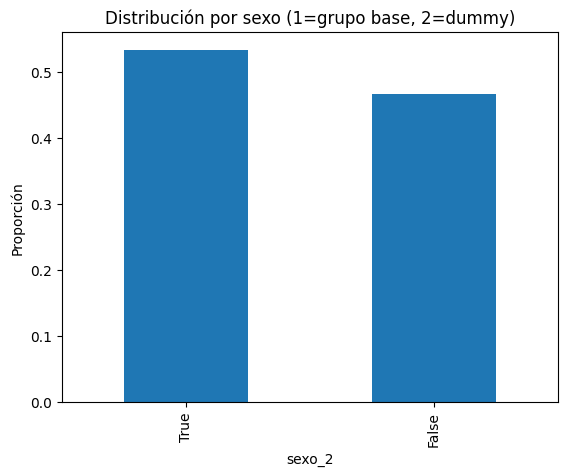

In [ ]:
df_sample["sexo_2"].value_counts(normalize=True).plot(kind="bar")

plt.title("Distribución por sexo (1=grupo base, 2=dummy)")
plt.ylabel("Proporción")
plt.show()

# Sexo con ingreso

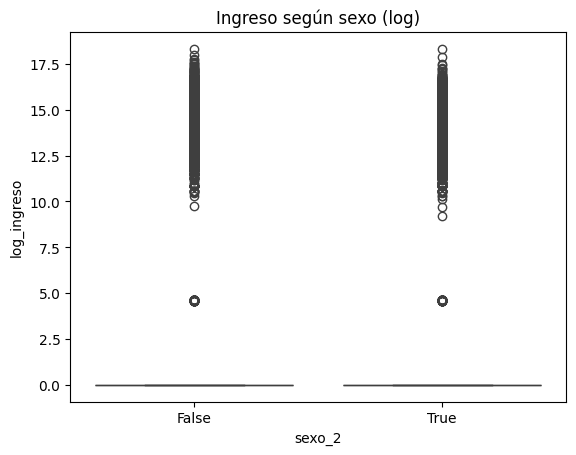

In [ ]:
import seaborn as sns

sns.boxplot(x="sexo_2", y="log_ingreso", data=df_sample)
plt.title("Ingreso según sexo (log)")
plt.show()

#

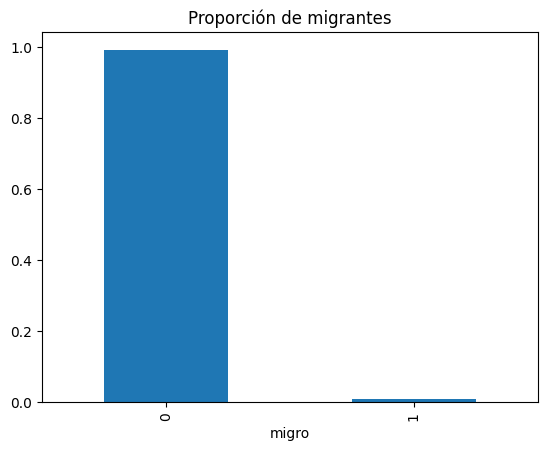

In [ ]:
df_sample["migro"].value_counts(normalize=True).plot(kind="bar")

plt.title("Proporción de migrantes")
plt.show()

# Edad y cotización a pensón

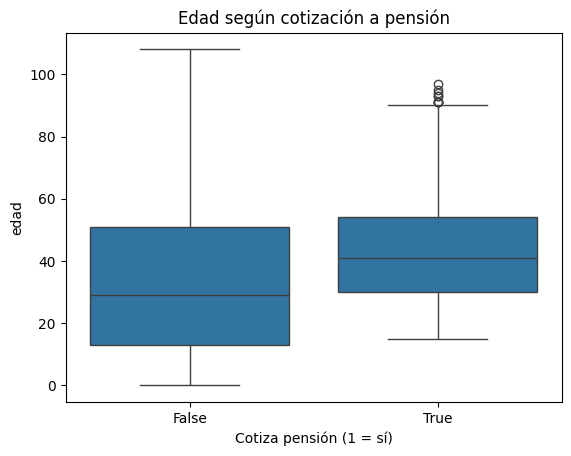

In [ ]:
sns.boxplot(x="cotiza_pension_2.0", y="edad", data=df_sample)

plt.title("Edad según cotización a pensión")
plt.xlabel("Cotiza pensión (1 = sí)")
plt.show()

# Sexo cotización a pensión

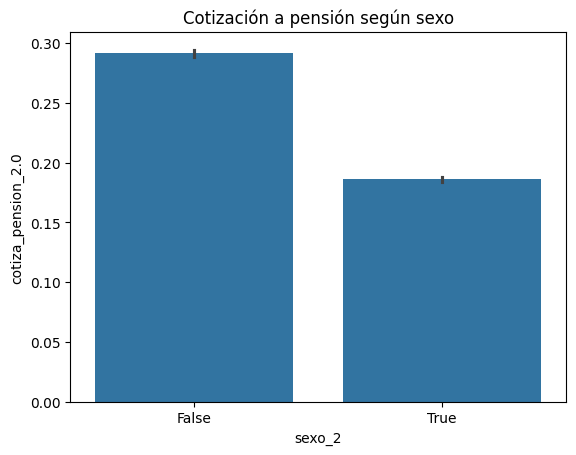

In [ ]:
sns.barplot(x="sexo_2", y="cotiza_pension_2.0", data=df_sample)

plt.title("Cotización a pensión según sexo")
plt.show()

#Edad ingreso

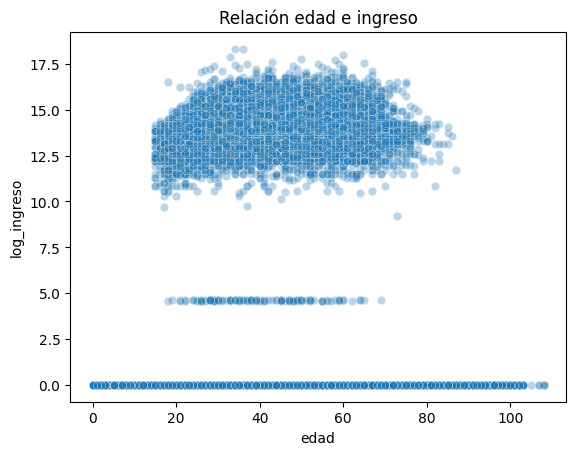

In [ ]:
sns.scatterplot(x="edad", y="log_ingreso", data=df_sample, alpha=0.3)

plt.title("Relación edad e ingreso")
plt.show()

# Horas extra con ingreso

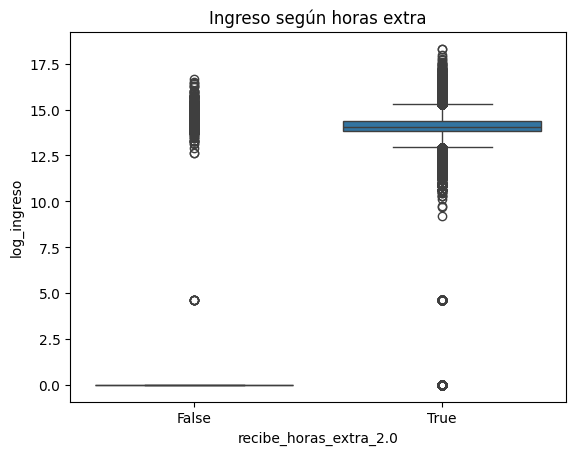

In [ ]:
sns.boxplot(x="recibe_horas_extra_2.0", y="log_ingreso", data=df_sample)

plt.title("Ingreso según horas extra")
plt.show()

# Sexo ingreso

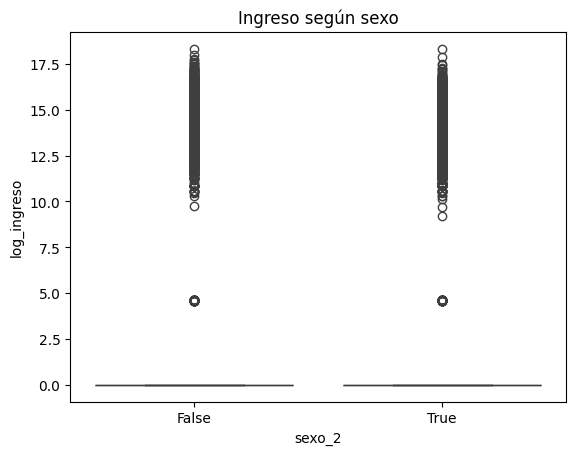

In [ ]:
sns.boxplot(x="sexo_2", y="log_ingreso", data=df_sample)

plt.title("Ingreso según sexo")
plt.show()

#Matriz de correlación

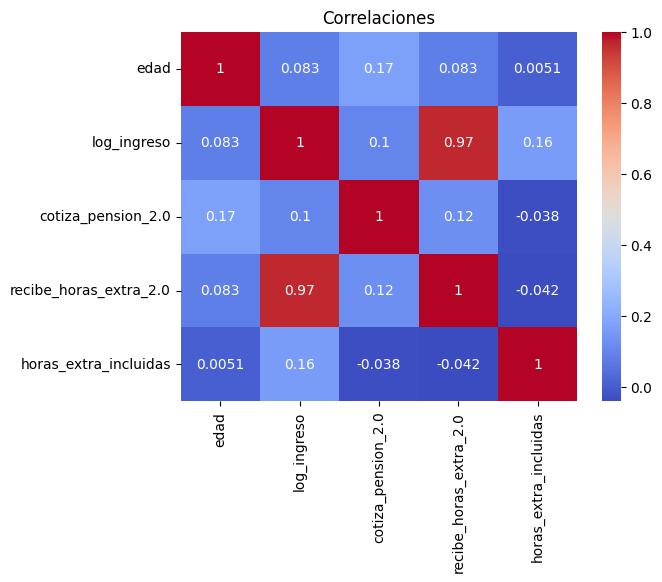

In [ ]:
cols = [
    "edad",
    "log_ingreso",
    "cotiza_pension_2.0",
    "recibe_horas_extra_2.0",
    "horas_extra_incluidas"
]

import seaborn as sns

sns.heatmap(df_sample[cols].corr(), annot=True, cmap="coolwarm")

plt.title("Correlaciones")
plt.show()

#Formalidad laboral

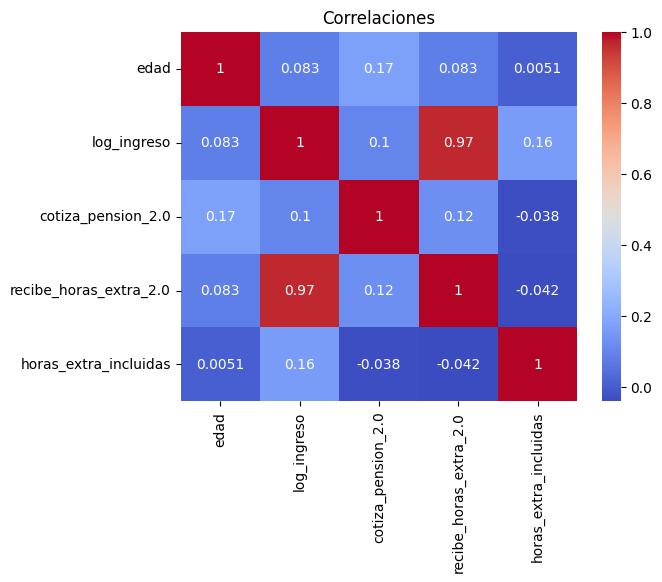

In [ ]:
cols = [
    "edad",
    "log_ingreso",
    "cotiza_pension_2.0",
    "recibe_horas_extra_2.0",
    "horas_extra_incluidas"
]

import seaborn as sns

sns.heatmap(df_sample[cols].corr(), annot=True, cmap="coolwarm")

plt.title("Correlaciones")
plt.show()